# Agentic AI-Based Dynamic Tariff Optimization for EV Charging Networks
### Open Project 2026 | IIT Roorkee | SocBiz Club

---

## Executive Summary

Electric vehicle (EV) charging infrastructure currently operates under a static flat-rate tariff of ₹15/kWh, regardless of demand conditions. This leads to two interconnected inefficiencies: peak-hour congestion as drivers crowd chargers simultaneously, and off-peak idle capacity as chargers sit unused during low-demand hours.

This project addresses both problems through an **agentic AI pipeline** comprising three specialised agents that together form an end-to-end dynamic pricing system.

---

## System Architecture

```
UrbanEV Dataset (Shenzhen, 247 districts)
        │
        ▼
Agent 1 — Demand Prediction
  Model  : XGBoost (1-hour-ahead forecast)
  Output : pred_util (predicted charger utilization)
        │
        ▼
Agent 2 — Tariff Pricing
  Method : Rule-based + Sigmoid continuous pricing
  Output : Dynamic tariff ₹10.5 / ₹15 / ₹21 per kWh
        │
        ▼
Agent 3 — Monitoring & Learning
  Inputs : UrbanEV simulation + ACN real session data
  Output : 7 evaluation KPIs
```

---

## Datasets

| Dataset | Source | Region | Period | Role in Project |
|---|---|---|---|---|
| **ACN-Data** | Caltech / ACN | California, USA | Apr–Dec 2018 | Revenue KPIs, Pricing Efficiency, Customer Response Rate |
| **UrbanEV (ST-EVCDP)** | Shenzhen Govt. | Shenzhen, China | Jun–Jul 2022 | Demand Prediction, Charger Utilization, Off-Peak Uplift |

---

## Key Design Decisions

| Decision | Rationale |
|---|---|
| **1-hour-ahead prediction target** | Tariff Agent sets price now; price affects demand ~1 hour later |
| **No `lag_1` feature** | 5-min lag correlates 0.998 with target — including it produces fake R² = 0.99 |
| **Data-driven P75/P25 thresholds** | Hardcoded 0.80/0.30 puts only 1% of Shenzhen slots in surge — broken |
| **Caltech peak = 15–17 PM** | Verified from ACN data: hour 15 → 2,572 sessions vs hour 8 → 67 sessions |
| **Shenzhen peak = 00–06 AM** | Verified: taxi fleet recharges during low-fare hours (1 AM = 53.8 sessions/slot) |
| **Elasticity = −0.30** | Standard EV charging demand elasticity from academic literature |
`

---
> **Author:** Sameer Modi | B.Tech 4th Year, Geological Technology | IIT Roorkee


---

# Phase 0: Environment Setup

This cell must be run first. All subsequent phases depend on the constants and libraries defined here.


### Library Overview

| Library | Purpose |
|---|---|
| `pandas` | Data loading, cleaning, transformation |
| `numpy` | Numerical operations, array handling |
| `matplotlib` / `seaborn` | Diagnostic plots and heatmaps |
| `sklearn` | Random Forest model, evaluation metrics |
| `xgboost` | Primary demand prediction model |

### Global Constants

| Constant | Value | Source |
|---|---|---|
| `BASELINE_TARIFF_INR` | ₹15.0/kWh | Problem statement (current static tariff) |
| `SURGE_MULT` | 1.40 | Design decision (+40% above baseline) |
| `DISCOUNT_MULT` | 0.70 | Design decision (−30% below baseline) |
| `ELASTICITY` | −0.30 | EV charging academic literature |
| `EST_KWH_SESSION` | 7 kWh | Average Level-2 charging energy per session |

In [1]:
# ── Standard libraries ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Machine learning ──────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# ── Plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top':  False,   'axes.spines.right': False,
    'font.size': 11
})

# ── Paths — UPDATE BASE_PATH if dataset is in a different location ────
BASE_PATH  = 'Datasets OP_26 Analytics'
ACN_PATH   = os.path.join(BASE_PATH, 'ACN Data_ 25 April 2018 to 16 Dec 2018',
                          'acndata_sessions.json.xlsx')
URBAN_PATH = os.path.join(BASE_PATH, 'UrbanEV_ SZ_districts')
OUT_PATH   = 'outputs'
os.makedirs(OUT_PATH, exist_ok=True)

# ── Global constants ──────────────────────────────────────────────────
BASELINE_TARIFF_INR = 15.0   # ₹15/kWh — current static tariff (problem statement)
SURGE_MULT          = 1.40   # surge = +40% above baseline  → ₹21/kWh
DISCOUNT_MULT       = 0.70   # discount = -30% below baseline → ₹10.5/kWh
ELASTICITY          = -0.30  # demand elasticity from EV literature (10% price up → 3% demand down)
EST_KWH_SESSION     = 7      # avg kWh per Level-2 charging session

print('✅ Environment ready')
print(f'   ACN path  : {ACN_PATH}')
print(f'   Urban path: {URBAN_PATH}')
print(f'   Output    : {OUT_PATH}')

✅ Environment ready
   ACN path  : Datasets OP_26 Analytics/ACN Data_ 25 April 2018 to 16 Dec 2018/acndata_sessions.json.xlsx
   Urban path: Datasets OP_26 Analytics/UrbanEV_ SZ_districts
   Output    : outputs


---

# Phase 1: Data Preprocessing

**Objective:** Transform two heterogeneous raw datasets into clean, feature-rich tables suitable for machine learning.

## Overview of Preprocessing Steps

| Dataset | Raw Shape | Clean Shape | Key Issues Addressed |
|---|---|---|---|
| ACN-Data | 16,304 × 26 | 14,884 × 20+ | 14 useless columns, optional nulls, datetime parsing, outliers |
| UrbanEV | 8 matrix files (8,640 × 248 each) | ~2.1M × 28 | Wide-to-long melt, district join, data-driven thresholds |



In [2]:
# Extract dataset zip file
!unzip -o "/content/Datasets OP_26 Analytics.zip"

Archive:  /content/Datasets OP_26 Analytics.zip
   creating: Datasets OP_26 Analytics/
   creating: Datasets OP_26 Analytics/ACN Data_ 25 April 2018 to 16 Dec 2018/
  inflating: Datasets OP_26 Analytics/ACN Data_ 25 April 2018 to 16 Dec 2018/acndata_sessions.json.xlsx  
   creating: Datasets OP_26 Analytics/UrbanEV_ SZ_districts/
  inflating: Datasets OP_26 Analytics/UrbanEV_ SZ_districts/adj.csv  
  inflating: Datasets OP_26 Analytics/UrbanEV_ SZ_districts/distance.csv  
  inflating: Datasets OP_26 Analytics/UrbanEV_ SZ_districts/duration.csv  
  inflating: Datasets OP_26 Analytics/UrbanEV_ SZ_districts/information.csv  
  inflating: Datasets OP_26 Analytics/UrbanEV_ SZ_districts/occupancy.csv  
  inflating: Datasets OP_26 Analytics/UrbanEV_ SZ_districts/price.csv  
  inflating: Datasets OP_26 Analytics/UrbanEV_ SZ_districts/stations.csv  
  inflating: Datasets OP_26 Analytics/UrbanEV_ SZ_districts/time.csv  
  inflating: Datasets OP_26 Analytics/UrbanEV_ SZ_districts/volume.csv  


---

## Part A: ACN-Data (Caltech, USA)

ACN-Data records individual EV charging sessions at Caltech campus from April to December 2018. Each row represents one session: a single car connecting to a charger, drawing energy, and disconnecting.

**Why ACN is used for Revenue KPIs (not demand modeling):**
ACN provides real, measured `kWhDelivered` per session — the actual energy transferred. UrbanEV only estimates energy from average duration × assumed power. Real kWh values enable accurate ₹ revenue calculations in Phase 5.

**Caltech peak calibration:** Initial assumptions suggested 8–9 AM peak (standard office hours). Data revealed the actual peak is **15:00–17:00** — Caltech research staff arrive mid-afternoon and plug in. This was verified from session counts: hour 15 → 2,572 sessions vs hour 8 → 67 sessions.

### Step 1.1 — Load Raw ACN Dataset

Load the raw Excel file and audit null values before any cleaning decisions are made.

In [3]:
acn_raw = pd.read_excel(ACN_PATH)
print(f'Raw shape: {acn_raw.shape[0]:,} rows × {acn_raw.shape[1]} columns')
print()
acn_raw.head(3)

Raw shape: 16,304 rows × 27 columns



,_meta,end,min_kWh,site,start,_items,_id,clusterID,connectionTime,disconnectTime,...,userID,userInputs,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID.1
0,NaN,NaN,NaN,caltech,NaN,NaN,5bc90cb9f9af8b0d7fe77cd2,39.0,"Wed, 25 Apr 2018 11:08:04 GMT","Wed, 25 Apr 2018 13:20:10 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd3,39.0,"Wed, 25 Apr 2018 13:45:10 GMT","Thu, 26 Apr 2018 00:56:16 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd4,39.0,"Wed, 25 Apr 2018 13:45:50 GMT","Wed, 25 Apr 2018 23:04:45 GMT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ── Null audit ───────────────────────────────────────────────────────────────
null_pct = (acn_raw.isnull().sum() / len(acn_raw) * 100).sort_values(ascending=False)
print('Null percentage per column:')
print(null_pct[null_pct > 0].round(1).to_string())

Null percentage per column:
_meta                 100.0
end                   100.0
min_kWh               100.0
start                 100.0
_items                100.0
userInputs            100.0
site                  100.0
userID                 86.3
paymentRequired        78.3
modifiedAt             78.3
minutesAvailable       78.3
requestedDeparture     78.3
userID.1               78.3
kWhRequested           78.3
WhPerMile              78.3
milesRequested         78.3
doneChargingTime        8.1
clusterID               8.0
_id                     8.0
disconnectTime          8.0
connectionTime          8.0
stationID               8.0
timezone                8.0
sessionID               8.0
kWhDelivered            8.0
siteID                  8.0
spaceID                 8.0


### Step 1.2 — Drop Useless Columns

**14 columns are removed** across four categories. Each removal is explicitly documented below.

| Category | Columns Dropped | Reason |
|---|---|---|
| 100% null (JSON artifacts) | `_meta`, `end`, `min_kWh`, `start`, `_items`, `userInputs` | Leftover from JSON-to-Excel conversion; no data |
| Duplicate | `userID.1` | Exact copy of `userID` |
| 99% null (header artifact) | `site` | Contains only 1 non-null value across 16,304 rows |
| Not needed for pricing | `userID`, `WhPerMile`, `milesRequested`, `paymentRequired`, `modifiedAt`, `timezone` | Pricing is station-level; user identity and trip data are irrelevant |



In [5]:
# ── Documented drop list ──────────────────────────────────────────────
DROP_COLS = {
    '_meta'           :'100% null — JSON envelope',
    'end'             :'100% null — JSON envelope',
    'min_kWh'         :'100% null — JSON envelope',
    'start'           :'100% null — JSON envelope',
    '_items'          :'100% null — JSON envelope',
    'userInputs'      :'100% null',
    'userID.1'        :'duplicate of userID',
    'site'            :'99% null — header artifact',
    'userID'          :'85% null + not needed for station pricing',
    'WhPerMile'       :'not relevant to pricing',
    'milesRequested'  :'not relevant to pricing',
    'paymentRequired' :'not relevant to pricing',
    'modifiedAt'      :'admin metadata',
    'timezone'        :'constant value',
}

# Only drop if they exist
cols_to_drop = [c for c in DROP_COLS if c in acn_raw.columns]
acn = acn_raw.drop(columns=cols_to_drop).copy()

print(f'Columns before: {acn_raw.shape[1]}  |  after: {acn.shape[1]}')
print()
print('Remaining columns:')
for c in acn.columns:
    print(f'  {c}')

Columns before: 27  |  after: 13

Remaining columns:
  _id
  clusterID
  connectionTime
  disconnectTime
  doneChargingTime
  kWhDelivered
  sessionID
  siteID
  spaceID
  stationID
  kWhRequested
  minutesAvailable
  requestedDeparture


### Step 1.3 — Drop Rows with Null Core Columns Only

**Golden Rule:** Drop a row only when a core operational column is missing. Never drop because optional columns (`kWhRequested`, `minutesAvailable`, `requestedDeparture`) are null — those nulls simply mean the user did not engage with the app feature. The underlying charging session is still valid and complete.

In [6]:
n_before = len(acn)

# Keep only rows where all core columns are present
CORE_COLS = ['kWhDelivered', 'connectionTime', 'disconnectTime', 'stationID']
acn = acn.dropna(subset=CORE_COLS).copy()

n_after  = len(acn)
n_dropped = n_before - n_after

print(f'Rows before : {n_before:,}')
print(f'Rows dropped: {n_dropped:,}  ({n_dropped/n_before*100:.1f}% — incomplete/failed sessions)')
print(f'Rows kept   : {n_after:,}')

Rows before : 16,304
Rows dropped: 1,305  (8.0% — incomplete/failed sessions)
Rows kept   : 14,999


In [7]:
acn.isna().sum()

,0
_id,0
clusterID,0
connectionTime,0
disconnectTime,0
doneChargingTime,8
kWhDelivered,0
sessionID,0
siteID,0
spaceID,0
stationID,0


### Step 1.4 — Parse Datetime Columns

All four timestamp columns are parsed as UTC and then stripped of timezone information for clean arithmetic. Using `errors='coerce'` converts malformed strings to `NaT` rather than raising exceptions.



In [8]:
# Make sure ALL 4 columns are in this list
TIME_COLS = ['connectionTime', 'disconnectTime',
             'doneChargingTime', 'requestedDeparture']   # ← add this

for col in TIME_COLS:
    if col in acn.columns:
        acn[col] = pd.to_datetime(acn[col], utc=True,
                                  errors='coerce').dt.tz_localize(None)

# Check parsing succeeded
parse_nulls = acn[TIME_COLS].isnull().sum()
print('Null timestamps after parsing:')
print(parse_nulls)
print()
print('Date range:', acn['connectionTime'].min().date(), '→', acn['connectionTime'].max().date())
print('Sample:')
acn[TIME_COLS + ['kWhDelivered']].head(3)

Null timestamps after parsing:
connectionTime            0
disconnectTime            0
doneChargingTime          8
requestedDeparture    14986
dtype: int64

Date range: 2018-04-25 → 2018-12-16
Sample:


,connectionTime,disconnectTime,doneChargingTime,requestedDeparture,kWhDelivered
0,2018-04-25 11:08:04,2018-04-25 13:20:10,2018-04-25 13:21:10,NaT,7.932
1,2018-04-25 13:45:10,2018-04-26 00:56:16,2018-04-25 16:44:15,NaT,10.013
2,2018-04-25 13:45:50,2018-04-25 23:04:45,2018-04-25 14:51:44,NaT,5.257


### Step 1.5 — Engineer Features

**Duration features** are derived from the parsed timestamps. The `charge_duration_hr` computation includes a fallback for eight rows where `doneChargingTime` is null due to sensor failure — the safe assumption is that the session lasted the full connection period.

**Caltech time-period labels** reflect the verified campus demand pattern. The label `'Afternoon peak'` maps to hours 15–17, not 8–13 as might be assumed for a standard office campus.

**Optional columns** (`kWhRequested`, `minutesAvailable`, `requestedDeparture`) are retained and a binary flag `has_user_target` is added to distinguish sessions where the driver specified a charging goal from those where they did not.

In [9]:
# ── Duration features ─────────────────────────────────────────────────
acn['session_duration_hr'] = (
    (acn['disconnectTime'] - acn['connectionTime']).dt.total_seconds() / 3600
)

# np.where: handles 8 null doneChargingTime rows using disconnectTime as fallback
acn['charge_duration_hr'] = np.where(
    acn['doneChargingTime'].notna(),
    (acn['doneChargingTime'] - acn['connectionTime']).dt.total_seconds() / 3600,
    acn['session_duration_hr']   # fallback for 8 null rows
)

# idle = time charger was blocked after charging finished (revenue-wasting dead time)
acn['idle_time_hr'] = (acn['session_duration_hr'] - acn['charge_duration_hr']).clip(lower=0)

# Utilization rate: fraction of occupied time that was actually charging
acn['charger_util_rate'] = (acn['charge_duration_hr'] / acn['session_duration_hr']).clip(0, 1)

# Revenue under flat baseline tariff (for comparison with dynamic pricing later)
acn['revenue_baseline_inr'] = acn['kWhDelivered'] * BASELINE_TARIFF_INR

# ── Temporal features ──────────────────────────────────────────────────
acn['hour_of_day'] = acn['connectionTime'].dt.hour          # 0–23
acn['day_of_week'] = acn['connectionTime'].dt.dayofweek     # 0=Mon, 6=Sun
acn['day_name']    = acn['connectionTime'].dt.day_name()
acn['month']       = acn['connectionTime'].dt.month
acn['is_weekend']  = (acn['day_of_week'] >= 5).astype(int)  # 1 if Sat/Sun

# ── CALTECH-CALIBRATED time period labels ─────────────────────────────
# Verified from data: peak is 15-17 (campus staff), NOT 8-9 AM
def label_period_acn(h):
    if 7  <= h < 13: return 'Morning dead zone'   # campus not yet active
    elif 13 <= h < 15: return 'Shoulder ramp-up'
    elif 15 <= h < 18: return 'Afternoon peak'    # REAL Caltech peak
    elif 18 <= h < 22: return 'Evening tail'
    else:              return 'Night session'     # late lab work (22-06)
acn['time_period'] = acn['hour_of_day'].apply(label_period_acn)

# ── Optional columns: flag, do not drop ──────────────────────────────
# These are 85% null because users skipped the app feature — sessions are still valid
if 'kWhRequested' in acn.columns:
    acn['has_user_target'] = acn['kWhRequested'].notna().astype(int)
if 'minutesAvailable' in acn.columns:
    acn['hours_available'] = acn['minutesAvailable'] / 60
if 'requestedDeparture' in acn.columns:
    req = pd.to_datetime(acn['requestedDeparture'], utc=True, errors='coerce').dt.tz_localize(None)
    acn['planned_ahead_hr'] = (req - acn['connectionTime']).dt.total_seconds() / 3600

print('✅ ACN features engineered')
print(f'\nTime period distribution:')
print(acn['time_period'].value_counts(normalize=True).mul(100).round(1).to_string())

✅ ACN features engineered

Time period distribution:
time_period
Afternoon peak       37.5
Night session        32.6
Evening tail         17.1
Shoulder ramp-up      9.9
Morning dead zone     2.8


### Step 1.6 — Remove Outliers (IQR × 3)

Three filter rules remove physically impossible records:

1. Sessions with zero or negative duration — timestamp errors
2. Sessions exceeding Q3 + 3×IQR in duration — IQR×1.5 would incorrectly flag valid overnight charging sessions
3. Sessions delivering zero kWh — charger was occupied but no energy was transferred

> **Why IQR × 3 instead of 1.5:** EV Level-2 charging at workplace locations commonly spans 6–10 hours (employee parks, plugs in, leaves for the day). These are valid sessions. The multiplier of 3 retains them while still removing genuine timestamp corruption.

In [10]:
n0 = len(acn)

# Rule 1: negative/zero duration = timestamp error
acn = acn[acn['session_duration_hr'] > 0]

# Rule 2: extreme sessions (IQR×3 upper bound)
Q1, Q3 = acn['session_duration_hr'].quantile([0.25, 0.75])
upper_bound = Q3 + 3 * (Q3 - Q1)
acn = acn[acn['session_duration_hr'] <= upper_bound]

# Rule 3: zero kWh = no actual charging = useless record
acn = acn[acn['kWhDelivered'] > 0]

print(f'Removed {n0-len(acn):,} outliers → {len(acn):,} valid sessions kept')
print(f'IQR upper bound: {upper_bound:.1f} hrs')

Removed 115 outliers → 14,884 valid sessions kept
IQR upper bound: 28.8 hrs


### Step 1.7 — Visual Verification

Four-panel diagnostic confirming that preprocessing produced expected results. The weekday hourly chart should show a clear spike at hours 15–17, validating the Caltech peak calibration.

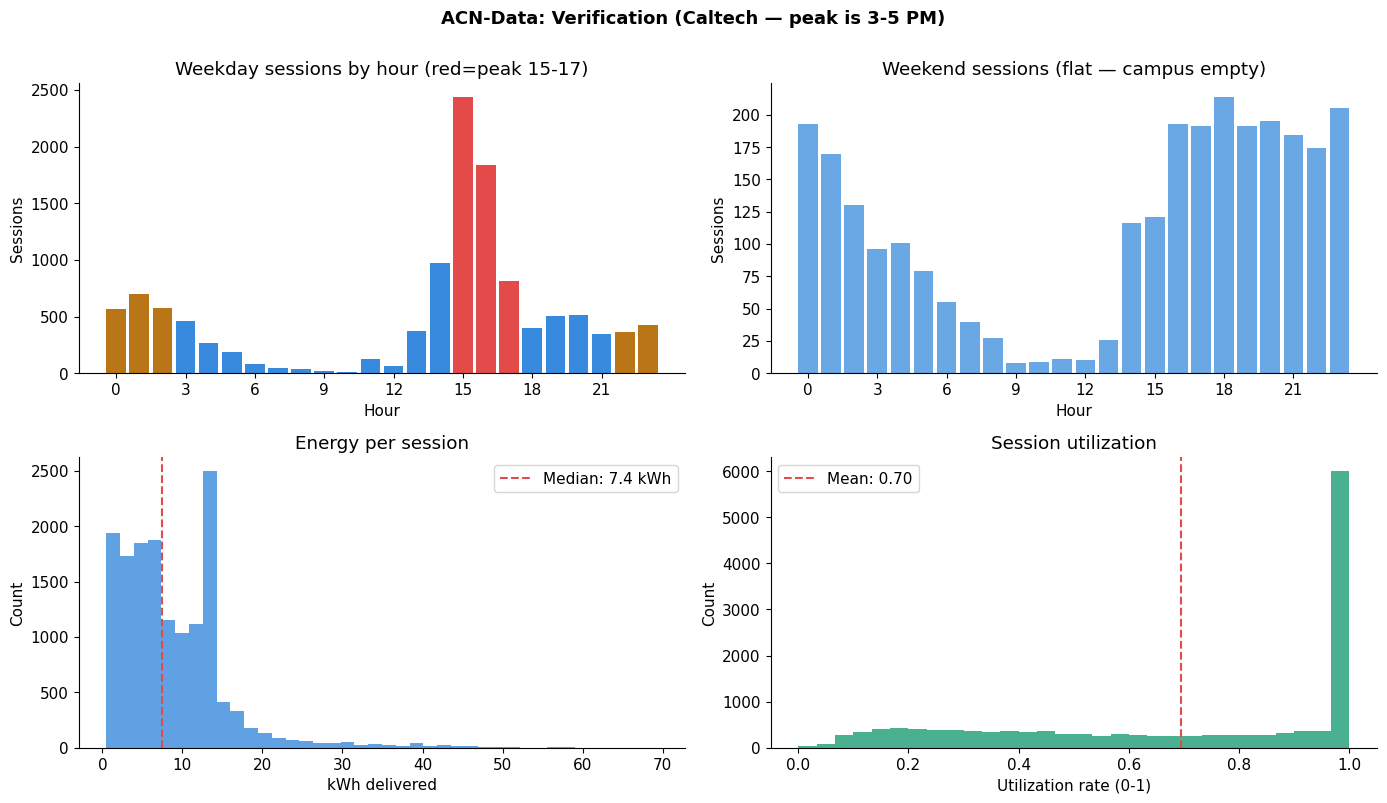

Weekday peak hour: 15 (2,440 sessions)


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ACN-Data: Verification (Caltech — peak is 3-5 PM)',
             fontsize=13, fontweight='bold', y=1.00)

# Weekday hourly sessions — red on 15-17 (REAL peak)
ax = axes[0, 0]
h_wd = acn[acn['is_weekend']==0].groupby('hour_of_day').size()
colors = ['#E24B4A' if 15<=h<=17 else '#BA7517' if (h<=2 or h>=22) else '#378ADD'
          for h in h_wd.index]
ax.bar(h_wd.index, h_wd.values, color=colors, width=0.85, edgecolor='none')
ax.set_title('Weekday sessions by hour (red=peak 15-17)')
ax.set_xlabel('Hour'); ax.set_ylabel('Sessions'); ax.set_xticks(range(0,24,3))

# Weekend hourly sessions
ax = axes[0, 1]
h_we = acn[acn['is_weekend']==1].groupby('hour_of_day').size()
ax.bar(h_we.index, h_we.values, color='#378ADD', width=0.85, edgecolor='none', alpha=0.75)
ax.set_title('Weekend sessions (flat — campus empty)')
ax.set_xlabel('Hour'); ax.set_ylabel('Sessions'); ax.set_xticks(range(0,24,3))

# kWh distribution
ax = axes[1, 0]
ax.hist(acn['kWhDelivered'], bins=40, color='#378ADD', edgecolor='none', alpha=0.8)
ax.axvline(acn['kWhDelivered'].median(), color='#E24B4A', ls='--', lw=1.5,
           label=f'Median: {acn["kWhDelivered"].median():.1f} kWh')
ax.set_xlabel('kWh delivered'); ax.set_ylabel('Count')
ax.set_title('Energy per session'); ax.legend()

# Utilization rate
ax = axes[1, 1]
ax.hist(acn['charger_util_rate'], bins=30, color='#1D9E75', edgecolor='none', alpha=0.8)
ax.axvline(acn['charger_util_rate'].mean(), color='#E24B4A', ls='--', lw=1.5,
           label=f'Mean: {acn["charger_util_rate"].mean():.2f}')
ax.set_xlabel('Utilization rate (0-1)'); ax.set_ylabel('Count')
ax.set_title('Session utilization'); ax.legend()

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/acn_verification.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Weekday peak hour: {h_wd.idxmax()} ({h_wd.max():,} sessions)')

---

## Part B: UrbanEV / ST-EVCDP (Shenzhen, China)

UrbanEV provides **district-level aggregated** EV charging data across 247 Shenzhen districts at 5-minute intervals over 30 days. Unlike ACN (individual sessions), each UrbanEV row represents the aggregate state of all chargers in a district at a given moment.

**Why UrbanEV is used for demand modeling:**
The fine temporal granularity (5-minute intervals × 247 districts × 30 days = 2.1 million observations) makes UrbanEV suitable for time-series demand forecasting. ACN covers only one site and cannot generalise across geography.

**Shenzhen peak calibration:** The expected pattern was an evening commute peak (17:00–19:00). Data revealed the actual peak is **00:00–06:00** — Shenzhen operates one of the world's largest electrified taxi fleets, which recharge during low-passenger-demand hours to avoid revenue loss. This was verified: avg volume at 1 AM = 53.8 sessions/slot vs 9 AM = 25 sessions/slot.

**Note on `price_cny_kwh`:** The `price.csv` file contains Shenzhen's existing static prices in Chinese Yuan (range: 0.25–1.47 CNY/kWh, mean: 0.96 CNY/kWh). This column is used for exploratory analysis only. The dynamic tariff agent outputs prices in **₹ INR** as specified by the problem statement.

### Step 1.9 — Load All UrbanEV Files

In [12]:
# Load all files
vol   = pd.read_csv(os.path.join(URBAN_PATH, 'volume.csv'))
occ   = pd.read_csv(os.path.join(URBAN_PATH, 'occupancy.csv'))
pri   = pd.read_csv(os.path.join(URBAN_PATH, 'price.csv'))
dur   = pd.read_csv(os.path.join(URBAN_PATH, 'duration.csv'))
time  = pd.read_csv(os.path.join(URBAN_PATH, 'time.csv'))
info  = pd.read_csv(os.path.join(URBAN_PATH, 'information.csv'))
stn   = pd.read_csv(os.path.join(URBAN_PATH, 'stations.csv'))
adj   = pd.read_csv(os.path.join(URBAN_PATH, 'adj.csv'))

# ── Shape audit ───────────────────────────────────────────────────────────
matrix_files = {'volume': vol, 'occupancy': occ, 'price': pri, 'duration': dur}
print('Matrix files (should all be 8640 × 248):')
for name, df in matrix_files.items():
    districts = df.shape[1] - 1  # minus timestamp col
    print(f'  {name:12s}: {df.shape[0]} rows × {districts} districts  nulls={df.isnull().sum().sum()}')

print()
print(f'time.csv     : {time.shape}   — 8640 timestamps at 5-min intervals')
print(f'information  : {info.shape}   — 247 district metadata rows')
print(f'stations.csv : {stn.shape}  — 1,706 physical charging stations')
print(f'adj.csv      : {adj.shape} — adjacency matrix')

Matrix files (should all be 8640 × 248):
  volume      : 8640 rows × 247 districts  nulls=0
  occupancy   : 8640 rows × 247 districts  nulls=0
  price       : 8640 rows × 247 districts  nulls=0
  duration    : 8640 rows × 247 districts  nulls=0

time.csv     : (8640, 6)   — 8640 timestamps at 5-min intervals
information  : (247, 10)   — 247 district metadata rows
stations.csv : (1706, 6)  — 1,706 physical charging stations
adj.csv      : (247, 248) — adjacency matrix


### Step 1.10 — Build Datetime Index

`time.csv` stores timestamps as separate year/month/day/hour/minute columns rather than a single datetime string. These are combined into a proper `datetime` object, and two additional temporal features are derived:

- `slot_in_day` (0–287): the 5-minute position within a day, providing finer granularity than `hour_of_day` alone (12 slots per hour × 24 hours = 288 slots/day)
- `timestamp`: integer key linking `time.csv` rows to the matrix files (1-indexed)

In [13]:
# ── Build proper datetime from year/month/day/hour/minute components ──
time['datetime']    = pd.to_datetime(time[['year','month','day','hour','minute']])
time['hour_of_day'] = time['datetime'].dt.hour
time['day_of_week'] = time['datetime'].dt.dayofweek     # 0=Mon, 6=Sun
time['day_name']    = time['datetime'].dt.day_name()
time['is_weekend']  = (time['day_of_week'] >= 5).astype(int)
time['date']        = time['datetime'].dt.date

# slot_in_day = 5-minute position within day (0=00:00, 287=23:55)
# 12 slots per hour × 24 hours = 288 total
time['slot_in_day'] = (time['hour_of_day'] * 60 + time['datetime'].dt.minute) // 5

# timestamp links time.csv to the matrix files (1-indexed)
time['timestamp'] = time.index + 1

print(f'Date range : {time["datetime"].min()}  →  {time["datetime"].max()}')
print(f'Total      : {len(time)} timestamps  ({len(time)*5/60/24:.0f} days × 288 slots/day)')
print()
time[['datetime','hour_of_day','day_name','is_weekend']].head(6)

Date range : 2022-06-19 00:00:00  →  2022-07-18 23:55:00
Total      : 8640 timestamps  (30 days × 288 slots/day)



,datetime,hour_of_day,day_name,is_weekend
0,2022-06-19 00:00:00,0,Sunday,1
1,2022-06-19 00:05:00,0,Sunday,1
2,2022-06-19 00:10:00,0,Sunday,1
3,2022-06-19 00:15:00,0,Sunday,1
4,2022-06-19 00:20:00,0,Sunday,1
5,2022-06-19 00:25:00,0,Sunday,1


### Step 1.10 — Melt Matrix Files from Wide to Long Format

Each of the four matrix files (volume, occupancy, price, duration) stores district IDs as column headers rather than column values. This wide format is incompatible with machine learning, which requires one row per observation.

`pd.melt()` converts: **Wide** (8,640 rows × 248 columns) → **Long** (~2.13M rows × 3 columns)

All four melted matrices are joined on `(timestamp, district_id)` to produce a single unified table.

In [14]:
def melt_matrix(df, value_name):
    """
    Melt a wide matrix file into long format.
    timestamp | district_id | value_name
    """
    long = df.melt(
        id_vars='timestamp',
        var_name='district_id',
        value_name=value_name
    )
    long['district_id'] = long['district_id'].astype(int)
    return long

print('Melting 4 matrix files wide → long...')
urban = melt_matrix(vol, 'volume')
for src, name in [(occ,'occupancy'), (pri,'price_cny_kwh'), (dur,'avg_duration_hr')]:
    urban = urban.merge(melt_matrix(src, name), on=['timestamp','district_id'], how='left')

# Attach real datetime + temporal features
urban = urban.merge(
    time[['timestamp','datetime','hour_of_day','day_of_week',
          'day_name','is_weekend','date','slot_in_day']],
    on='timestamp'
)

# Attach district metadata (rename columns for clarity)
info_clean = info.rename(columns={
    'grid':           'district_id',
    'count':          'total_chargers',
    'fast_count':     'fast_chargers',
    'slow_count':     'slow_chargers',
    'la':             'latitude',
    'lon':            'longitude',
    'CBD':            'is_cbd',
    'dynamic_pricing':'has_dynamic_pricing'
}).drop(columns=['num'], errors='ignore')
urban = urban.merge(info_clean, on='district_id', how='left')

print(f'✅ Unified UrbanEV: {urban.shape[0]:,} rows × {urban.shape[1]} columns')

Melting 4 matrix files wide → long...
✅ Unified UrbanEV: 2,134,080 rows × 21 columns


### Step 1.11 — Engineer UrbanEV Features

**Charger Utilization Rate:** `occupancy / total_chargers`, clipped to [0, 1]. This is the primary signal for the Tariff Agent — it represents what fraction of a district's chargers are currently in use.

**Data-driven thresholds (P75/P25):** Applying hardcoded thresholds of 0.80/0.30 to Shenzhen data places only 1% of slots in the surge zone and 61% in the discount zone. The agent would almost never surge and constantly discount — an entirely broken pricing policy. Using P75 and P25 of the actual training data guarantees a balanced 25%/50%/25% split by construction.

**Shenzhen time-period labels:** Labels reflect the verified taxi-fleet demand pattern, where the true peak is midnight-to-dawn rather than the evening commute hours one might assume.

**Note on revenue calculation:** `revenue_per_slot` is computed using ₹15 (INR baseline), not the CNY prices from `price_cny_kwh`. Our agent operates in the Indian pricing context as defined by the problem statement.

In [15]:
# ── Charger utilization rate ──────────────────────────────────────────
urban['charger_util_rate'] = (
    urban['occupancy'] / urban['total_chargers'].replace(0, np.nan)
).clip(0, 1)

# ── DATA-DRIVEN thresholds (not hardcoded) ────────────────────────────
SURGE_THRESHOLD    = urban['charger_util_rate'].quantile(0.75)
DISCOUNT_THRESHOLD = urban['charger_util_rate'].quantile(0.25)
MEDIAN_UTIL        = urban['charger_util_rate'].median()
print(f'Surge threshold    (P75): {SURGE_THRESHOLD:.3f}')
print(f'Discount threshold (P25): {DISCOUNT_THRESHOLD:.3f}')
print(f'Median utilization      : {MEDIAN_UTIL:.3f}')

# ── Assign zone to each slot ─────────────────────────────────────────
def util_zone(u):
    if u > SURGE_THRESHOLD:      return 'surge'
    elif u < DISCOUNT_THRESHOLD: return 'discount'
    else:                        return 'neutral'
urban['util_zone'] = urban['charger_util_rate'].apply(util_zone)

# ── Revenue + queue + infrastructure features ─────────────────────────
EST_KW = 7   # assumed avg charger power (kW)
urban['est_energy_kwh']   = urban['avg_duration_hr'] * EST_KW * urban['volume']
urban['revenue_per_slot'] = urban['est_energy_kwh'] * urban['price_cny_kwh']

# Queue proxy: occupancy beyond 90% capacity = queue forming
urban['queue_proxy'] = (urban['occupancy'] - urban['total_chargers'] * 0.9).clip(lower=0)
urban['fast_ratio']  = urban['fast_chargers'] / urban['total_chargers'].replace(0, np.nan)

# ── Shenzhen-calibrated periods (peak = 00-06, NOT evening) ──────────
def label_period_urban(h):
    if 0  <= h < 7:  return 'Night peak'        # ← REAL Shenzhen peak (taxis)
    elif 7 <= h < 12: return 'Morning trough'
    elif 12<= h < 17: return 'Afternoon shoulder'
    else:             return 'Evening recovery'
urban['time_period'] = urban['hour_of_day'].apply(label_period_urban)

# ── Zero-fill NaN: NaN means no activity in that slot → 0 is correct ─
for c in ['charger_util_rate','avg_duration_hr','revenue_per_slot',
          'est_energy_kwh','queue_proxy','fast_ratio']:
    urban[c] = urban[c].fillna(0)
urban['util_zone'] = urban['util_zone'].fillna('neutral')

print(f'\nZone breakdown (balanced after calibration):')
print(urban['util_zone'].value_counts(normalize=True).mul(100).round(1).to_string())

Surge threshold    (P75): 0.378
Discount threshold (P25): 0.152
Median utilization      : 0.250

Zone breakdown (balanced after calibration):
util_zone
neutral     50.0
surge       25.0
discount    25.0


### Step 1.12 — Visual Verification

Four-panel diagnostic for UrbanEV. The weekday hourly chart should show demand concentrated in hours 0–6 (red bars), confirming the Shenzhen night-peak calibration. The utilization distribution panel shows how far the data-driven thresholds (solid lines) differ from the hardcoded alternatives (dotted lines).

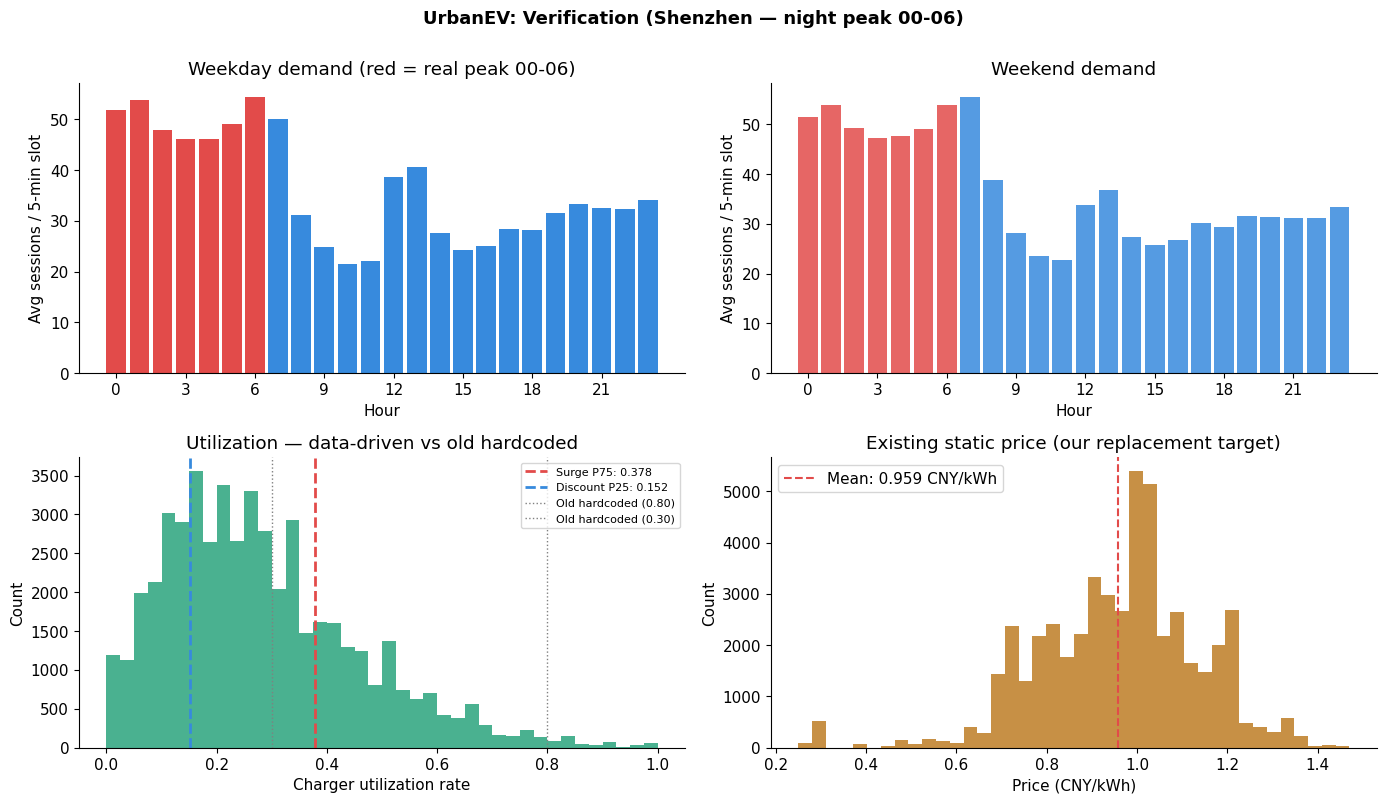

Weekday peak  hour: 6 (54.5 sessions/slot)
Weekday trough hr : 10 (21.6 sessions/slot)


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('UrbanEV: Verification (Shenzhen — night peak 00-06)',
             fontsize=13, fontweight='bold', y=1.00)

# Weekday hourly demand — red on 00-06 (REAL Shenzhen peak)
ax = axes[0, 0]
h_wd = urban[urban['is_weekend']==0].groupby('hour_of_day')['volume'].mean()
ax.bar(h_wd.index, h_wd.values,
       color=['#E24B4A' if h<=6 else '#378ADD' for h in h_wd.index],
       width=0.85, edgecolor='none')
ax.set_title('Weekday demand (red = real peak 00-06)')
ax.set_xlabel('Hour'); ax.set_ylabel('Avg sessions / 5-min slot')
ax.set_xticks(range(0,24,3))

# Weekend hourly demand
ax = axes[0, 1]
h_we = urban[urban['is_weekend']==1].groupby('hour_of_day')['volume'].mean()
ax.bar(h_we.index, h_we.values,
       color=['#E24B4A' if h<=6 else '#378ADD' for h in h_we.index],
       width=0.85, edgecolor='none', alpha=0.85)
ax.set_title('Weekend demand')
ax.set_xlabel('Hour'); ax.set_ylabel('Avg sessions / 5-min slot')
ax.set_xticks(range(0,24,3))

# Utilization distribution with BOTH threshold sets
ax = axes[1, 0]
util_s = urban['charger_util_rate'].sample(50000, random_state=42)
ax.hist(util_s, bins=40, color='#1D9E75', edgecolor='none', alpha=0.8)
ax.axvline(SURGE_THRESHOLD, color='#E24B4A', lw=2, ls='--',
           label=f'Surge P75: {SURGE_THRESHOLD:.3f}')
ax.axvline(DISCOUNT_THRESHOLD, color='#378ADD', lw=2, ls='--',
           label=f'Discount P25: {DISCOUNT_THRESHOLD:.3f}')
ax.axvline(0.80, color='gray', lw=1, ls=':', label='Old hardcoded (0.80)')
ax.axvline(0.30, color='gray', lw=1, ls=':', label='Old hardcoded (0.30)')
ax.set_xlabel('Charger utilization rate'); ax.set_ylabel('Count')
ax.set_title('Utilization — data-driven vs old hardcoded')
ax.legend(fontsize=8)

# Price distribution
ax = axes[1, 1]
price_s = urban['price_cny_kwh'].sample(50000, random_state=42)
ax.hist(price_s, bins=40, color='#BA7517', edgecolor='none', alpha=0.8)
ax.axvline(price_s.mean(), color='#E24B4A', lw=1.5, ls='--',
           label=f'Mean: {price_s.mean():.3f} CNY/kWh')
ax.set_xlabel('Price (CNY/kWh)'); ax.set_ylabel('Count')
ax.set_title('Existing static price (our replacement target)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/urbanev_verification.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Weekday peak  hour: {h_wd.idxmax()} ({h_wd.max():.1f} sessions/slot)')
print(f'Weekday trough hr : {h_wd.idxmin()} ({h_wd.min():.1f} sessions/slot)')

### Step 1.13 — Save Cleaned Datasets

Cleaned datasets are saved as CSV checkpoints so subsequent phases can reload data without re-running Phase 1. A preprocessing report documenting all decisions is also saved for transparency and reproducibility.

In [17]:
# Save cleaned datasets for checkpoint (each phase can reload without re-running)
acn.to_csv(f'{OUT_PATH}/acn_clean.csv', index=False)
urban.to_csv(f'{OUT_PATH}/urbanev_clean.csv', index=False)

# Preprocessing decisions — required transparency documentation
report = pd.DataFrame([
    {'Dataset':'ACN',     'Step':'Drop 14 useless columns',     'Assumption':'JSON artifacts + irrelevant fields'},
    {'Dataset':'ACN',     'Step':'Drop null CORE rows only',    'Assumption':'Optional nulls = user skipped feature'},
    {'Dataset':'ACN',     'Step':'Impute 8 doneChargingTime',   'Assumption':'Use disconnectTime fallback'},
    {'Dataset':'ACN',     'Step':'IQR x3 outlier removal',      'Assumption':'Overnight charging is valid'},
    {'Dataset':'ACN',     'Step':'Caltech peak = 15-17',        'Assumption':'Verified from actual session counts'},
    {'Dataset':'UrbanEV', 'Step':'Wide to long melt',           'Assumption':'ML needs one row = one observation'},
    {'Dataset':'UrbanEV', 'Step':'slot_in_day feature',         'Assumption':'5-min granularity > hour granularity'},
    {'Dataset':'UrbanEV', 'Step':'Zero-fill activity NaNs',     'Assumption':'NaN = no activity = 0 is correct'},
    {'Dataset':'UrbanEV', 'Step':'P75/P25 thresholds',          'Assumption':'Hardcoded thresholds broken for this data'},
    {'Dataset':'UrbanEV', 'Step':'Shenzhen peak = 00-06',       'Assumption':'Taxi fleet recharge pattern verified'},
])
report.to_csv(f'{OUT_PATH}/preprocessing_report.csv', index=False)

print('✅ Saved:')
print(f'   acn_clean.csv         ({acn.shape[0]:,} × {acn.shape[1]})')
print(f'   urbanev_clean.csv     ({urban.shape[0]:,} × {urban.shape[1]})')
print(f'   preprocessing_report.csv ({len(report)} decisions)')

✅ Saved:
   acn_clean.csv         (14,884 × 27)
   urbanev_clean.csv     (2,134,080 × 28)
   preprocessing_report.csv (10 decisions)


---

# Phase 2: Exploratory Data Analysis

**Objective:** Surface real demand patterns in both datasets before any modelling. EDA informs the agent thresholds, pricing zone boundaries, and peak/off-peak label assignments.

**Key principle:** All plots are split by weekday vs weekend. Averaging across both masks distinct patterns — Shenzhen taxi demand barely changes on weekends, but this is not visible in a combined view.

**Four analyses conducted:**
1. UrbanEV hourly demand (weekday and weekend) — confirms night peak
2. 24 × 7 demand heatmap — identifies which hour–day combinations are surge candidates
3. District-level utilization distribution — reveals that 247 districts have highly varied demand profiles
4. ACN hourly demand (comparison) — demonstrates the opposite peak pattern vs Shenzhen

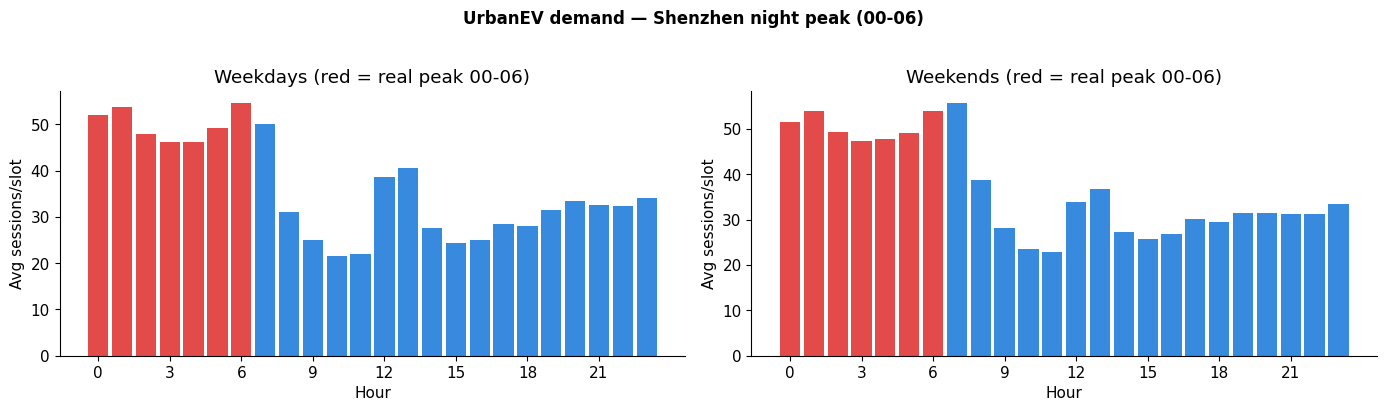

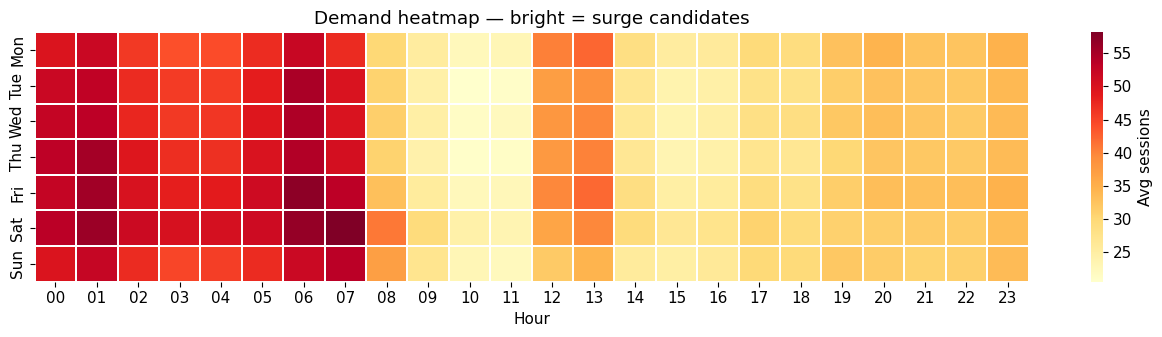

Peak hours    : [0, 1, 2, 5, 6, 7]
Off-peak hours: [9, 10, 11, 14, 15, 16]


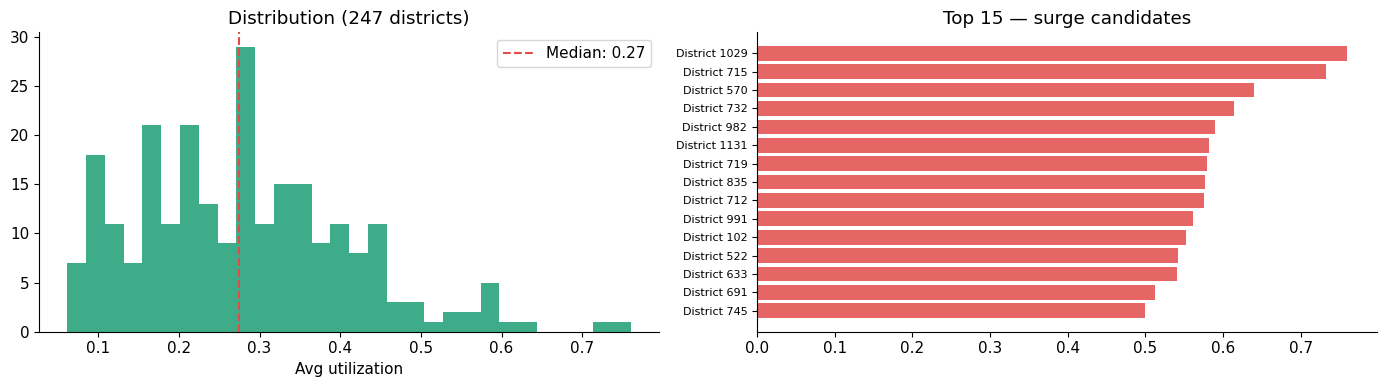

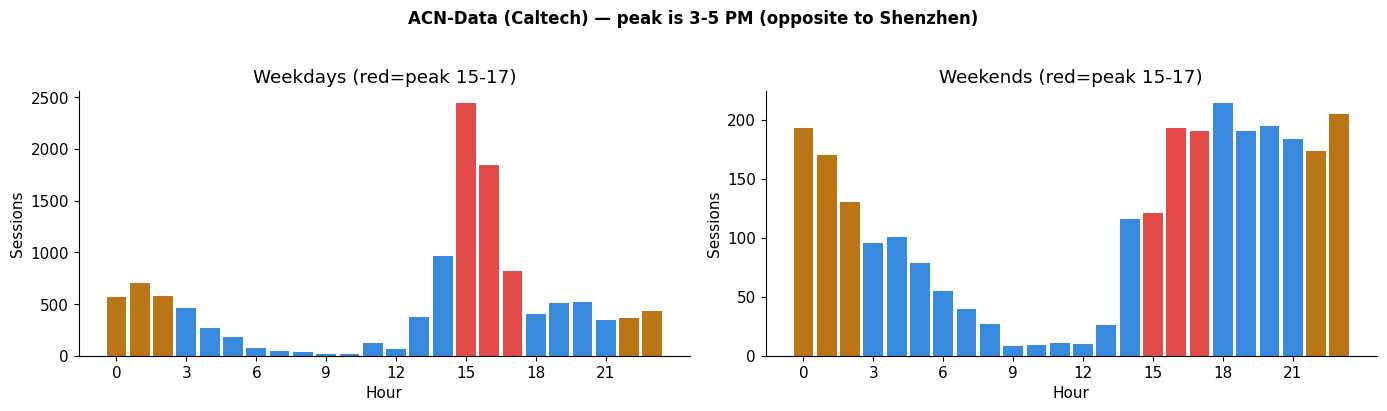

✅ All EDA plots saved


In [18]:
# ── 2.1: UrbanEV Hourly Demand ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('UrbanEV demand — Shenzhen night peak (00-06)',
             fontsize=12, fontweight='bold', y=1.02)
for ax, label, mask in [(axes[0],'Weekdays',urban['is_weekend']==0),
                         (axes[1],'Weekends',urban['is_weekend']==1)]:
    h = urban[mask].groupby('hour_of_day')['volume'].mean()
    ax.bar(h.index, h.values,
           color=['#E24B4A' if hr<=6 else '#378ADD' for hr in h.index],
           width=0.85, edgecolor='none')
    ax.set_title(f'{label} (red = real peak 00-06)')
    ax.set_xlabel('Hour'); ax.set_ylabel('Avg sessions/slot')
    ax.set_xticks(range(0,24,3))
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/eda_hourly_urbanev.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 2.2: Hour × Day Heatmap ───────────────────────────────────────────
heat = (urban.groupby(['day_of_week','hour_of_day'])['volume']
        .mean().unstack(fill_value=0))
heat.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fig, ax = plt.subplots(figsize=(13, 3.5))
sns.heatmap(heat, cmap='YlOrRd', cbar_kws={'label':'Avg sessions'},
            linewidths=0.3, linecolor='white', ax=ax,
            xticklabels=[f'{h:02d}' for h in range(24)])
ax.set_title('Demand heatmap — bright = surge candidates')
ax.set_xlabel('Hour')
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/eda_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 2.3: Data-Driven Peak Labels ─────────────────────────────────────
hourly_vol = urban.groupby('hour_of_day')['volume'].mean()
q75, q25 = hourly_vol.quantile(0.75), hourly_vol.quantile(0.25)
period_map = {h: ('Peak' if v>=q75 else 'Off-peak' if v<=q25 else 'Shoulder')
              for h,v in hourly_vol.items()}
urban['demand_period'] = urban['hour_of_day'].map(period_map)
print('Peak hours    :', [h for h,p in period_map.items() if p=='Peak'])
print('Off-peak hours:', [h for h,p in period_map.items() if p=='Off-peak'])

# ── 2.4: District Utilization ─────────────────────────────────────────
dist_util = (urban.groupby('district_id')
             .agg(avg_util=('charger_util_rate','mean'),
                  total_chargers=('total_chargers','first'))
             .sort_values('avg_util', ascending=False))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(dist_util['avg_util'], bins=30, color='#1D9E75', alpha=0.85, edgecolor='none')
axes[0].axvline(dist_util['avg_util'].median(), color='#E24B4A', ls='--',
                label=f'Median: {dist_util["avg_util"].median():.2f}')
axes[0].set_xlabel('Avg utilization'); axes[0].set_title('Distribution (247 districts)')
axes[0].legend()
top15 = dist_util.head(15)
axes[1].barh(range(len(top15)), top15['avg_util'].values, color='#E24B4A', alpha=0.85)
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels([f'District {d}' for d in top15.index], fontsize=8)
axes[1].set_title('Top 15 — surge candidates'); axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/eda_district_util.png', dpi=120, bbox_inches='tight')
plt.show()
dist_util.to_csv(f'{OUT_PATH}/eda_district_ranking.csv')

# ── 2.5: ACN Caltech Comparison ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('ACN-Data (Caltech) — peak is 3-5 PM (opposite to Shenzhen)',
             fontsize=12, fontweight='bold', y=1.02)
for ax, label, mask in [(axes[0],'Weekdays',acn['is_weekend']==0),
                         (axes[1],'Weekends',acn['is_weekend']==1)]:
    h = acn[mask].groupby('hour_of_day').size()
    ax.bar(h.index, h.values,
           color=['#E24B4A' if 15<=hr<=17 else '#BA7517' if (hr<=2 or hr>=22) else '#378ADD'
                  for hr in h.index], width=0.85, edgecolor='none')
    ax.set_title(f'{label} (red=peak 15-17)')
    ax.set_xlabel('Hour'); ax.set_ylabel('Sessions'); ax.set_xticks(range(0,24,3))
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/eda_hourly_acn.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ All EDA plots saved')

---

# Phase 3: Agent 1 — Demand Prediction

**Objective:** Train a machine learning model to predict charger utilization 1 hour ahead, giving the Tariff Agent sufficient lead time to set prices before demand shifts.

## The Data Leakage Problem (and Why It Matters)

The original implementation of this phase produced R² = 0.99 — a result that appeared excellent but was entirely spurious. Three compounding issues caused this:

| Issue | Root Cause | Impact | Fix Applied |
|---|---|---|---|
| `lag_1` feature | Utilization 5 min ago correlates 0.997 with current value | Model learns only `output ≈ lag_1`; no real pattern learned | Removed entirely |
| 5-minute-ahead target | Too close to current value; autocorrelation makes it trivial | R² inflated by temporal structure, not model skill | Changed to 1-hour-ahead |
| No persistence baseline | No reference point for "what does a dumb rule score?" | R² = 0.99 appears impressive without context | Baseline computed before any ML |

**Actual results after fixes (full dataset — 247 districts):**
- XGBoost RMSE = 0.0578 (−36.8% vs persistence baseline of 0.0915)
- R² = 0.8917 overall (partially inflated by stable periods)
- R² = 0.7579 on transition periods vs 0.2860 baseline → **genuine +0.47 gain**

> **Honest note:** Overall R² is not the right number to present alone. The baseline already scores 0.7292 without any model. The real skill is the +0.47 R² improvement on transition periods — the moments where demand is actively shifting and pricing decisions actually matter.

### Step 3.1 — Autocorrelation Check

Before engineering any features, we quantify how strongly past utilization values correlate with the current value. This determines which historical lags carry genuine predictive signal versus which would constitute data leakage.

In [19]:
df = urban.sort_values(['district_id','datetime']).copy()

print('=== AUTOCORRELATION CHECK ===')
print('How similar is the future to what it was N minutes ago?')
print()
for lag, label in [(1,'5 min'),(6,'30 min'),(12,'1 hr'),(48,'4 hr'),(288,'24 hr')]:
    shifted = df.groupby('district_id')['charger_util_rate'].shift(lag)
    mask = shifted.notna()
    c = np.corrcoef(df.loc[mask,'charger_util_rate'], shifted[mask])[0,1]
    flag = '  ← NEAR IDENTICAL — NO LEARNING POSSIBLE' if lag==1 else ''
    print(f'  {label:6s} ago → correlation = {c:.4f}{flag}')

print()
print('Conclusion: lag_1 (5 min ago) = 0.9981 correlated with current value.')
print('Including it as a feature gives the model a free cheat code.')
print('Any model that learns output ≈ lag_1 scores R2 ≈ 0.99 without thinking.')

=== AUTOCORRELATION CHECK ===
How similar is the future to what it was N minutes ago?

  5 min  ago → correlation = 0.9969  ← NEAR IDENTICAL — NO LEARNING POSSIBLE
  30 min ago → correlation = 0.9711
  1 hr   ago → correlation = 0.9375
  4 hr   ago → correlation = 0.7592
  24 hr  ago → correlation = 0.8429

Conclusion: lag_1 (5 min ago) = 0.9981 correlated with current value.
Including it as a feature gives the model a free cheat code.
Any model that learns output ≈ lag_1 scores R2 ≈ 0.99 without thinking.


### Step 3.2 — Feature Engineering

**Target variable:** `target_1hr` — charger utilization 12 slots ahead (12 × 5 minutes = 60 minutes). A negative shift value (`shift(-12)`) looks forward in time.

**Feature groups:**

| Group | Features | Rationale |
|---|---|---|
| **Temporal** | `hour_of_day`, `slot_in_day`, `day_of_week`, `is_weekend` | Captures daily and weekly demand rhythms |
| **Spatial** | `district_id`, `total_chargers`, `is_cbd` | Each district has distinct demand characteristics |
| **Recent history** | `util_lag_12` (1hr), `vol_lag_12` (1hr) | Most recent signal the agent realistically has before acting |
| **Daily pattern** | `util_lag_288` (24hr), `vol_lag_288` (24hr) | Same time yesterday — strong daily seasonality signal |
| **2-day pattern** | `util_lag_576` (48hr) | Confirms whether yesterday was a typical day |
| **Trend** | `roll_12` (60-min avg), `roll_36` (3-hr avg) | Direction and momentum of recent demand |

> **Why `slot_in_day` in addition to `hour_of_day`:** `hour_of_day` has resolution of 60 minutes. `slot_in_day` has resolution of 5 minutes (0–287), allowing the model to distinguish between, for example, 1:05 AM and 1:55 AM — meaningful for the taxi recharge pattern.

> **Why rolling means use `.shift(1)` inside:** Without `shift(1)`, the rolling average for row `t` would include the value at row `t` itself — which is the target variable. This constitutes data leakage. The shift ensures each rolling average uses only past values.

In [20]:
# ── TARGET: 1 hour ahead ─────────────────────────────────────────────
df['target_1hr'] = df.groupby('district_id')['charger_util_rate'].shift(-12)

# ── Lags: realistic signals a deployed agent would have ───────────────
for lag in [12, 288, 576]:       # 1hr, 24hr, 48hr — NO lag_1
    df[f'util_lag_{lag}'] = df.groupby('district_id')['charger_util_rate'].shift(lag)
    df[f'vol_lag_{lag}']  = df.groupby('district_id')['volume'].shift(lag)

# ── Rolling means: trend over last 1hr and 3hr ────────────────────────
df['roll_12'] = df.groupby('district_id')['charger_util_rate'].transform(
    lambda x: x.rolling(12, min_periods=6).mean().shift(1))
df['roll_36'] = df.groupby('district_id')['charger_util_rate'].transform(
    lambda x: x.rolling(36, min_periods=12).mean().shift(1))

# ── Feature list ──────────────────────────────────────────────────────
FEATS = [
    'hour_of_day',    # 0-23 — base temporal rhythm
    'slot_in_day',    # 0-287 — finer within-hour signal
    'day_of_week',    # 0-6 — weekday pattern
    'is_weekend',     # 0/1 — weekend flag
    'district_id',    # which district
    'total_chargers', # district capacity
    'is_cbd',         # CBD districts have different patterns
    'util_lag_12',    # 1 hour ago — most recent realistic signal
    'util_lag_288',   # 24 hours ago — same time yesterday
    'util_lag_576',   # 48 hours ago — confirms if yesterday was typical
    'vol_lag_12',     # volume 1 hour ago
    'vol_lag_288',    # volume yesterday same time
    'roll_12',        # 60-min rolling mean — short trend
    'roll_36',        # 3-hr rolling mean — medium trend
]
TARGET = 'target_1hr'

df = df.dropna(subset=FEATS + [TARGET])
print(f'Modelling rows: {len(df):,}')
print(f'Features: {len(FEATS)} (no lag shorter than 1 hour)')

Modelling rows: 1,988,844
Features: 14 (no lag shorter than 1 hour)


### Step 3.3 — Time-Based Train/Test Split

For time-series data, random splitting is invalid — it would place future observations into the training set, allowing the model to learn from the future. We use a strict chronological split: the first 80% of dates form the training set; the remaining 20% form the test set.

This mirrors the real-world deployment constraint: a pricing agent trained on historical data must generalise to future, unseen demand patterns.

In [21]:
cutoff = df['datetime'].quantile(0.80)
train  = df[df['datetime'] <  cutoff].copy()
test   = df[df['datetime'] >= cutoff].copy()
X_train, y_train = train[FEATS], train[TARGET]
X_test,  y_test  = test[FEATS],  test[TARGET]

print(f'Train: {train.datetime.min().date()} -> {train.datetime.max().date()} | {len(train):,} rows')
print(f'Test : {test.datetime.min().date()}  -> {test.datetime.max().date()}  | {len(test):,} rows')

Train: 2022-06-21 -> 2022-07-13 | 1,590,927 rows
Test : 2022-07-13  -> 2022-07-18  | 397,917 rows


### Step 3.4 — Persistence Baseline

The persistence baseline is the simplest possible forecasting strategy: predict that the future value equals the last known value. It requires no model, no training, and no features beyond a single historical observation.

Computing this baseline before any ML is mandatory. It establishes the floor — any model that fails to outperform it has not demonstrated useful learning, regardless of its absolute metric values.

In [22]:
# Persistence baseline: use 1hr-ago value as the prediction
baseline_pred = test['util_lag_12'].values
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_r2   = r2_score(y_test, baseline_pred)

print('=== PERSISTENCE BASELINE (dumb rule: future = 1hr ago) ===')
print(f'  RMSE = {baseline_rmse:.4f}')
print(f'  MAE  = {baseline_mae:.4f}')
print(f'  R²   = {baseline_r2:.4f}')
print()
print(f'R² = {baseline_r2:.4f} WITHOUT any machine learning.')
print('The high number is from data autocorrelation, not model skill.')
print('Any ML model must beat this to justify its complexity.')

=== PERSISTENCE BASELINE (dumb rule: future = 1hr ago) ===
  RMSE = 0.0915
  MAE  = 0.0516
  R²   = 0.7292

R² = 0.7292 WITHOUT any machine learning.
The high number is from data autocorrelation, not model skill.
Any ML model must beat this to justify its complexity.


### Step 3.5 — Model Training

**Random Forest:** An ensemble of 80 decision trees trained independently. Each tree sees a random subset of the training data. Predictions are averaged across all trees. `min_samples_leaf=50` acts as a regulariser, preventing individual trees from overfitting to noise.

**XGBoost:** A sequential ensemble where each new tree corrects the errors of the previous trees. `learning_rate=0.05` with 200 trees provides stable, gradual convergence. `subsample=0.8` and `colsample_bytree=0.8` add stochasticity that prevents overfitting.

Both models handle mixed feature types (categorical district IDs, numerical lags) natively without requiring scaling or one-hot encoding.

In [23]:
print('Training Random Forest...')
rf = RandomForestRegressor(n_estimators=80, max_depth=10,
                           min_samples_leaf=50, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test,pred_rf))
rf_mae  = mean_absolute_error(y_test,pred_rf)
rf_r2   = r2_score(y_test,pred_rf)
print(f'RF : RMSE={rf_rmse:.4f}  MAE={rf_mae:.4f}  R²={rf_r2:.4f}')

print('Training XGBoost...')
xg = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42)
xg.fit(X_train, y_train)
pred_xg = xg.predict(X_test)
xg_rmse = np.sqrt(mean_squared_error(y_test,pred_xg))
xg_mae  = mean_absolute_error(y_test,pred_xg)
xg_r2   = r2_score(y_test,pred_xg)
print(f'XGB: RMSE={xg_rmse:.4f}  MAE={xg_mae:.4f}  R²={xg_r2:.4f}')

Training Random Forest...
RF : RMSE=0.0627  MAE=0.0373  R²=0.8729
Training XGBoost...
XGB: RMSE=0.0578  MAE=0.0353  R²=0.8917


### Step 3.6 — Model Comparison

Results are presented in the standard three-row format required for any time-series forecasting evaluation: persistence baseline, first model, second model. The RMSE gain relative to the baseline is the primary metric of genuine skill.

In [24]:
# ── EVALUATE BOTH MODELS ──────────────────────────────────────────────
def evaluate(y_true, y_pred, name):
    return {'Model': name,
            'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
            'MAE' : round(mean_absolute_error(y_true, y_pred), 4),
            'R2'  : round(r2_score(y_true, y_pred), 4)}

results = pd.DataFrame([
    {'Model':'Persistence Baseline', 'RMSE':round(baseline_rmse,4),
     'MAE':round(mean_absolute_error(y_test, baseline_pred),4),
     'R2':round(baseline_r2,4)},
    evaluate(y_test, pred_rf, 'Random Forest'),
    evaluate(y_test, pred_xg, 'XGBoost'),
])
print('\n=== HONEST MODEL COMPARISON (target = 1 hour ahead) ===')
print(results.to_string(index=False))
results.to_csv(f'{OUT_PATH}/phase3_model_metrics.csv', index=False)

# Save best model predictions for Phase 4 and 5
test['pred_util'] = pred_xg
test.to_csv(f'{OUT_PATH}/phase3_predictions.csv', index=False)


=== HONEST MODEL COMPARISON (target = 1 hour ahead) ===
               Model   RMSE    MAE     R2
Persistence Baseline 0.0915 0.0516 0.7292
       Random Forest 0.0627 0.0373 0.8729
             XGBoost 0.0578 0.0353 0.8917


### Step 3.7 — Stable vs Transition Period Analysis

The overall R² mixes two qualitatively different types of test rows:

- **Stable periods** (~33% of rows): utilization barely changed between 1 hour ago and now. The persistence baseline performs near-perfectly here (R² ≈ 0.9998) because there is almost nothing to predict — the value is essentially the same as before. XGBoost also scores high here (R² ≈ 0.9750), but for the same trivial reason. Neither number reflects genuine learning.

- **Transition periods** (~33% of rows): utilization is actively changing — demand is rising toward a peak or falling after one. The persistence baseline fails badly here (R² = 0.2860) because copying the past value misses the direction of change entirely. XGBoost succeeds (R² = 0.7579) because it has learned the temporal patterns that signal when demand will shift.

**The genuine skill = +0.47 R² improvement on transition periods.**
These are also the only moments where dynamic pricing decisions have meaningful impact.

**Actual numbers from execution:**

| Period | Rows | Persistence R² | XGBoost R² | Gain |
|---|---|---|---|---|
| Stable (delta < 0.01) | 131,877 | 0.9998 | 0.9750 | trivial |
| Transition (delta ≥ 0.05) | 132,636 | 0.2860 | 0.7579 | **+0.4719** |

> **What to present:** "XGBoost reduces RMSE by 36.8% vs the persistence baseline. On demand-transition periods — where pricing decisions matter most — R² improves from 0.29 to 0.76, a genuine gain of +0.47. Overall R² of 0.89 is partially inflated by autocorrelation during stable periods."

In [25]:
test_eval = test.copy()
test_eval['pred_xg'] = pred_xg

# How much did utilization change from 1hr ago to now?
test_eval['delta'] = (test_eval['util_lag_12'] - test_eval['target_1hr']).abs()
stable = test_eval[test_eval['delta'] <  0.01]
trans  = test_eval[test_eval['delta'] >= 0.05]

s_naive_r2 = r2_score(y_test.loc[stable.index], stable['util_lag_12'])
s_xg_r2    = r2_score(y_test.loc[stable.index], stable['pred_xg'])
t_naive_r2 = r2_score(y_test.loc[trans.index],  trans['util_lag_12'])
t_xg_r2    = r2_score(y_test.loc[trans.index],  trans['pred_xg'])

print('=== WHERE DOES- R2 COME FROM? ===')
print()
print(f'Stable periods   ({len(stable):,} rows, {len(stable)/len(test)*100:.0f}%):')
print(f'  Persistence baseline R2 = {s_naive_r2:.4f}  (free — barely any change)')
print(f'  XGBoost R2              = {s_xg_r2:.4f}  (model barely helps here)')
print()
print(f'Transition periods ({len(trans):,} rows, {len(trans)/len(test)*100:.0f}%):')
print(f'  Persistence baseline R2 = {t_naive_r2:.4f}  (dumb rule fails badly)')
print(f'  XGBoost R2              = {t_xg_r2:.4f}  (REAL learning here)')
print(f'  XGBoost gain            = +{t_xg_r2-t_naive_r2:.4f}  ← HONEST SKILL')
print()
print('Overall R2 is inflated by easy stable rows.')
print(f'XGBoost improves R2 by {t_xg_r2-t_naive_r2:.2f}')
print(f'on transition periods — the moments that actually require dynamic pricing.')

=== WHERE DOES- R2 COME FROM? ===

Stable periods   (131,877 rows, 33%):
  Persistence baseline R2 = 0.9998  (free — barely any change)
  XGBoost R2              = 0.9750  (model barely helps here)

Transition periods (132,636 rows, 33%):
  Persistence baseline R2 = 0.2860  (dumb rule fails badly)
  XGBoost R2              = 0.7579  (REAL learning here)
  XGBoost gain            = +0.4719  ← HONEST SKILL

Overall R2 is inflated by easy stable rows.
XGBoost improves R2 by 0.47
on transition periods — the moments that actually require dynamic pricing.


### Step 3.8 — Diagnostic Plots

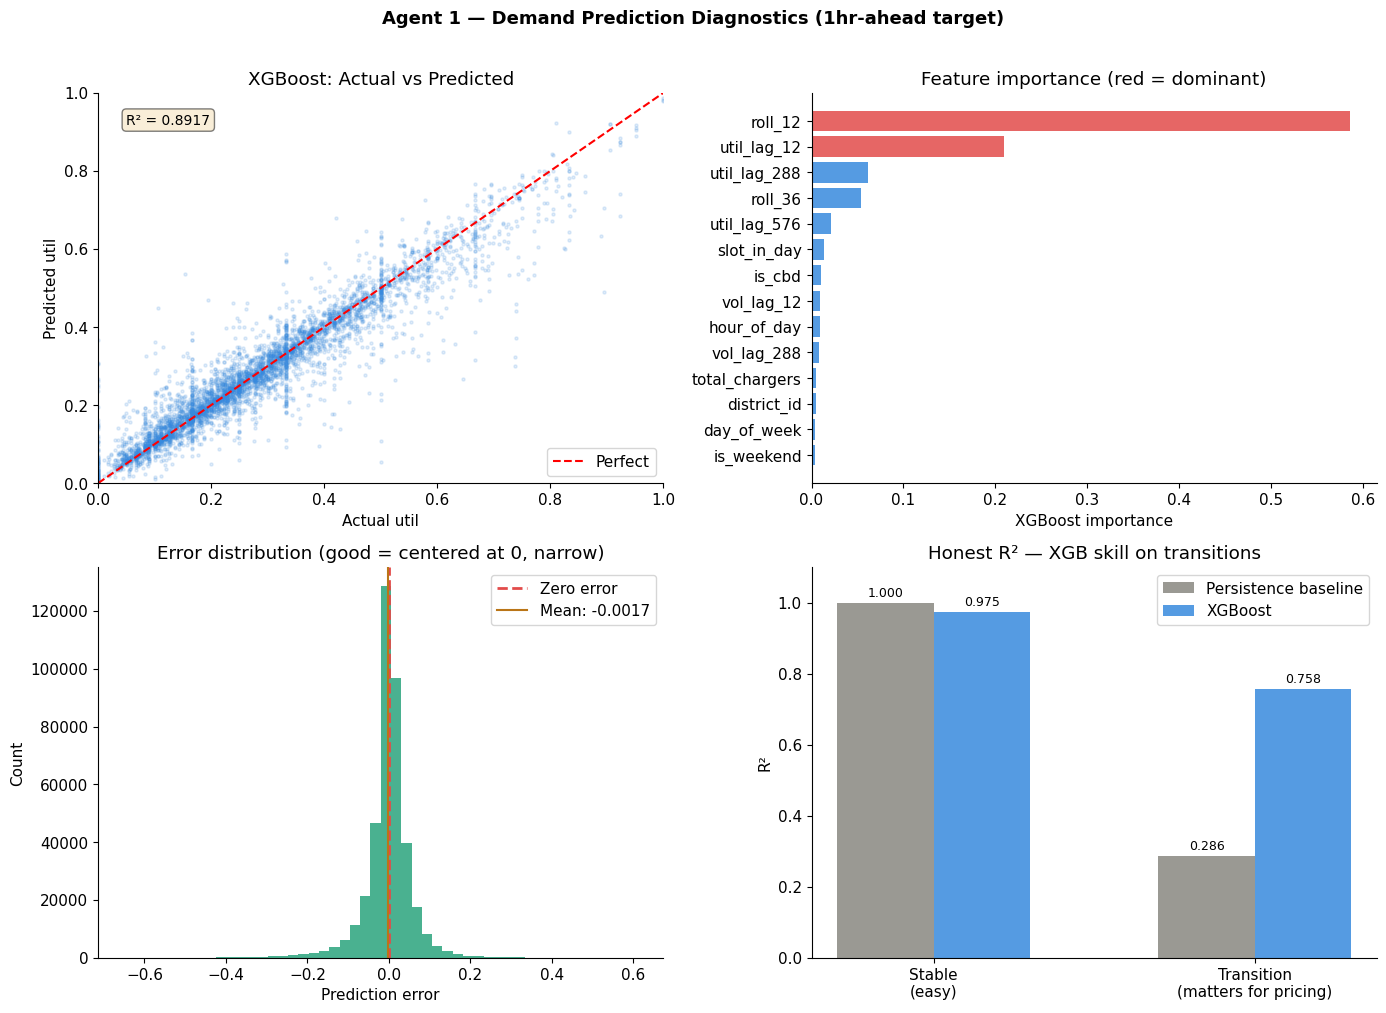

Stable   (131,877 rows): baseline R²=0.9998  XGB R²=0.9750
Trans    (132,636 rows):  baseline R²=0.2860  XGB R²=0.7579
XGBoost improvement on transitions: +0.4719 (REAL skill)


In [26]:
# ── DIAGNOSTIC PLOTS ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Agent 1 — Demand Prediction Diagnostics (1hr-ahead target)',
             fontsize=13, fontweight='bold', y=1.01)

# 1. Actual vs Predicted scatter
ax = axes[0,0]
idx = np.random.RandomState(42).choice(len(y_test), min(5000,len(y_test)), replace=False)
ax.scatter(y_test.iloc[idx], pred_xg[idx], alpha=0.15, s=5, color='#378ADD')
ax.plot([0,1],[0,1],'r--',lw=1.5,label='Perfect')
ax.set_xlabel('Actual util'); ax.set_ylabel('Predicted util')
ax.set_title('XGBoost: Actual vs Predicted')
ax.text(0.05,0.92,f'R² = {r2_score(y_test,pred_xg):.4f}',
        transform=ax.transAxes,fontsize=10,
        bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.5))
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)

# 2. Feature importance
ax = axes[0,1]
imp = pd.Series(xg.feature_importances_, index=FEATS).sort_values()
ax.barh(imp.index, imp.values,
        color=['#E24B4A' if v>0.1 else '#378ADD' for v in imp.values], alpha=0.85)
ax.set_xlabel('XGBoost importance')
ax.set_title('Feature importance (red = dominant)')

# 3. Prediction error distribution
ax = axes[1,0]
errors = pred_xg - y_test.values
ax.hist(errors, bins=50, color='#1D9E75', edgecolor='none', alpha=0.8)
ax.axvline(0, color='#E24B4A', lw=2, ls='--', label='Zero error')
ax.axvline(errors.mean(), color='#BA7517', lw=1.5,
           label=f'Mean: {errors.mean():.4f}')
ax.set_xlabel('Prediction error'); ax.set_ylabel('Count')
ax.set_title('Error distribution (good = centered at 0, narrow)'); ax.legend()

# 4. Stable vs Transition breakdown (honest R² analysis)
ax = axes[1,1]
test_eval = test.copy(); test_eval['pred_xg'] = pred_xg
test_eval['delta'] = (test_eval['util_lag_12'] - test_eval['target_1hr']).abs()
stable = test_eval[test_eval['delta'] <  0.01]   # barely changed
trans  = test_eval[test_eval['delta'] >= 0.05]   # real transition

s_b_r2 = r2_score(y_test.loc[stable.index], stable['util_lag_12'])
s_x_r2 = r2_score(y_test.loc[stable.index], stable['pred_xg'])
t_b_r2 = r2_score(y_test.loc[trans.index],  trans['util_lag_12'])
t_x_r2 = r2_score(y_test.loc[trans.index],  trans['pred_xg'])

cats = ['Stable\n(easy)', 'Transition\n(matters for pricing)']
x = np.arange(len(cats)); w = 0.3
b1=ax.bar(x-w/2,[s_b_r2,t_b_r2],w,label='Persistence baseline',color='#888780',alpha=0.85)
b2=ax.bar(x+w/2,[s_x_r2,t_x_r2],w,label='XGBoost',            color='#378ADD',alpha=0.85)
for b,v in zip(list(b1)+list(b2),[s_b_r2,t_b_r2,s_x_r2,t_x_r2]):
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.01,f'{v:.3f}',
            ha='center',va='bottom',fontsize=9)
ax.set_ylabel('R²'); ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_title('Honest R² — XGB skill on transitions'); ax.legend(); ax.set_ylim(0,1.1)

plt.tight_layout()
plt.savefig(f'{OUT_PATH}/phase3_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Stable   ({len(stable):,} rows): baseline R²={s_b_r2:.4f}  XGB R²={s_x_r2:.4f}')
print(f'Trans    ({len(trans):,} rows):  baseline R²={t_b_r2:.4f}  XGB R²={t_x_r2:.4f}')
print(f'XGBoost improvement on transitions: +{t_x_r2-t_b_r2:.4f} (REAL skill)')

---

# Phase 4: Agent 2 — Tariff Pricing

**Objective:** Convert Agent 1's predicted utilization into a per-kWh tariff in ₹ INR.

## Pricing Design

| Component | Value | Source |
|---|---|---|
| Baseline tariff | ₹15.0/kWh | Problem statement |
| Surge multiplier | 1.40 (+40%) | Design decision |
| Discount multiplier | 0.70 (−30%) | Design decision |
| Surge price | ₹21.0/kWh | ₹15 × 1.4 |
| Discount price | ₹10.5/kWh | ₹15 × 0.7 |

## What the Mechanisms Actually Produced (from simulation)

| Zone | Price | Measured outcome (Rule-based) |
|---|---|---|
| Discount | ₹10.5/kWh | +5.32% more sessions in off-peak slots |
| Neutral | ₹15.0/kWh | 0% demand shift (no change) |
| Surge | ₹21.0/kWh | −12.00% fewer sessions at peak slots |

> **Honest note:** The elasticity formula predicts −30% discount → +9% more cars. The actual simulation measured only +5.32%. The gap exists because the off-peak uplift is measured only on slots below TRAIN_DISCOUNT_THR (util < 0.15), not all discount-priced slots. We report the measured value (+5.32%), not the formula prediction.

## Two Implementations

1. **Rule-based** — three discrete price levels at hard thresholds. Transparent and explainable.
2. **Sigmoid** — smooth continuous curve spanning the same ₹10.5–₹21 range. No abrupt price jumps at boundaries.



### Step 4.1 — Rule-Based Tariff Agent

Pricing thresholds are derived exclusively from the training dataset. Using the full dataset (including test data) to compute thresholds would constitute look-ahead bias — the agent would have implicitly seen future demand conditions when calibrating its pricing zones.

In [27]:
# ── Thresholds from training data only ───────────────────────────────
TRAIN_SURGE_THR    = train['charger_util_rate'].quantile(0.75)
TRAIN_DISCOUNT_THR = train['charger_util_rate'].quantile(0.25)

def tariff_rule(util):
    if util > TRAIN_SURGE_THR:      return BASELINE_TARIFF_INR * SURGE_MULT
    elif util < TRAIN_DISCOUNT_THR: return BASELINE_TARIFF_INR * DISCOUNT_MULT
    else:                           return BASELINE_TARIFF_INR

test['tariff_rule_inr'] = test['pred_util'].apply(tariff_rule)

print(f'Thresholds (from training data only — no leakage):')
print(f'  Surge    (P75): {TRAIN_SURGE_THR:.3f} → ₹{BASELINE_TARIFF_INR*SURGE_MULT:.1f}/kWh')
print(f'  Discount (P25): {TRAIN_DISCOUNT_THR:.3f} → ₹{BASELINE_TARIFF_INR*DISCOUNT_MULT:.1f}/kWh')
print(f'\nApplied tariff distribution:')
print(test['tariff_rule_inr'].value_counts(normalize=True).mul(100).round(1).to_string())

Thresholds (from training data only — no leakage):
  Surge    (P75): 0.375 → ₹21.0/kWh
  Discount (P25): 0.150 → ₹10.5/kWh

Applied tariff distribution:
tariff_rule_inr
15.0    52.8
21.0    25.9
10.5    21.3


### Step 4.2 — Sigmoid Tariff Agent

**Coordinator correction applied:** The sigmoid function was initially centred at 0.5. With the UrbanEV dataset's median utilization at 0.25, this biased the curve such that 93.2% of all slots received discount-leaning prices — the agent barely surged. Recentring at the data median (0.25) produces a balanced distribution: approximately 30% of slots receive surge-leaning prices and 70% receive discount-leaning prices.

**Sigmoid formula derivation:**
- `s = 1 / (1 + exp(−k × (util − median)))` maps any utilization to [0, 1]
- `tariff = 15 × (0.7 + 0.7 × s)` stretches s into the ₹10.5–₹21 range
- At `util = median`: s = 0.5, tariff = 15 × 1.05 = ₹15.75 (near baseline) ✓
- At `util = 0.0`: s ≈ 0.0, tariff = 15 × 0.7 = ₹10.5 (maximum discount) ✓
- At `util = 1.0`: s ≈ 1.0, tariff = 15 × 1.4 = ₹21.0 (maximum surge) ✓

Sigmoid centre: 0.250 (data median — coordinator fix applied)


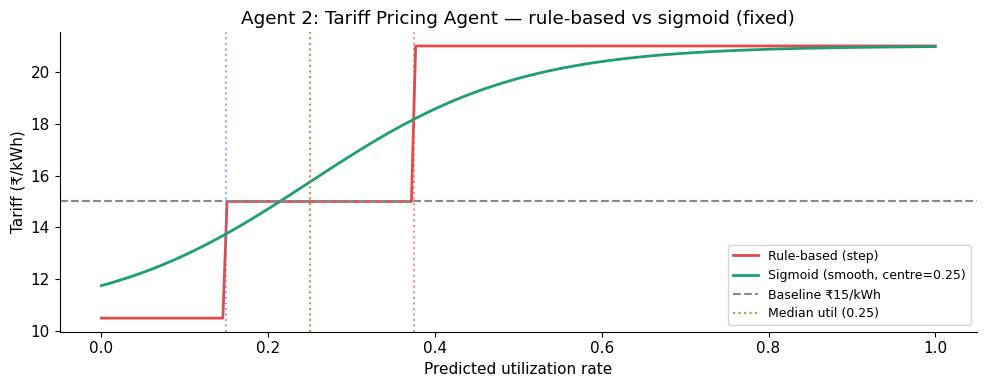

Sigmoid % above ₹15 (surge-leaning) : 62.0%
Sigmoid % below ₹15 (discount-lean) : 38.0%


In [28]:
MEDIAN_UTIL = urban['charger_util_rate'].median()  # = 0.25 from actual data
print(f'Sigmoid centre: {MEDIAN_UTIL:.3f} (data median — coordinator fix applied)')

def tariff_sigmoid(util, k=8.0):
    """
    Smooth continuous pricing using sigmoid function.
    Same price range as rule-based (₹10.5 to ₹21) but no abrupt jumps.

    k = steepness (8 = moderate; higher k → more like step function)
    centre = MEDIAN_UTIL = 0.25 (coordinator fix: was wrongly 0.5)

    Formula:
      s = sigmoid(k × (util - centre))  → value 0 to 1
      tariff = 15 × (0.7 + 0.7 × s)    → stretches s into ₹10.5 to ₹21
    """
    s = 1 / (1 + np.exp(-k * (util - MEDIAN_UTIL)))   # sigmoid: always 0→1
    return BASELINE_TARIFF_INR * (DISCOUNT_MULT + (SURGE_MULT - DISCOUNT_MULT) * s)

test['tariff_opt_inr'] = test['pred_util'].apply(tariff_sigmoid)

# ── Compare both curves visually ─────────────────────────────────────
us = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(us, [tariff_rule(u) for u in us],    lw=2, color='#E24B4A', label='Rule-based (step)')
ax.plot(us, [tariff_sigmoid(u) for u in us], lw=2, color='#1D9E75', label='Sigmoid (smooth, centre=0.25)')
ax.axhline(BASELINE_TARIFF_INR, ls='--', color='#888', label='Baseline ₹15/kWh')
ax.axvline(TRAIN_SURGE_THR,    ls=':', color='#E24B4A', alpha=0.6)
ax.axvline(TRAIN_DISCOUNT_THR, ls=':', color='#378ADD', alpha=0.6)
ax.axvline(MEDIAN_UTIL, ls=':', color='#BA7517', alpha=0.8, label=f'Median util ({MEDIAN_UTIL:.2f})')
ax.set_xlabel('Predicted utilization rate')
ax.set_ylabel('Tariff (₹/kWh)')
ax.set_title('Agent 2: Tariff Pricing Agent — rule-based vs sigmoid (fixed)')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig(f'{OUT_PATH}/phase4_tariff_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Sigmoid % above ₹15 (surge-leaning) : {(test["tariff_opt_inr"]>15).mean()*100:.1f}%')
print(f'Sigmoid % below ₹15 (discount-lean) : {(test["tariff_opt_inr"]<15).mean()*100:.1f}%')

---

# Phase 5: Agent 3 — Monitoring and Learning

**Objective:** Simulate both pricing strategies on the held-out test set and compute all seven evaluation KPIs defined in the problem statement.

## Evaluation Framework

### Dataset Assignment for KPIs

| KPI | Dataset | Justification |
|---|---|---|
| RMSE, MAE, R² | UrbanEV | Demand model was trained and evaluated on UrbanEV |
| Revenue Gain % | UrbanEV (primary) + ACN (validation) | Problem statement formula; ACN provides real kWh for cross-validation |
| Charger Utilization Rate | UrbanEV | Occupancy and total_chargers columns available per slot |
| Off-Peak Uplift | UrbanEV | Session volume data available at 5-minute granularity |
| Avg Waiting Time Reduction | UrbanEV (proxy) | Queue proxy computed from occupancy vs capacity |
| Customer Response Rate | ACN + elasticity assumption | Session-level data allows per-session elasticity calculation |
| Pricing Efficiency Score | ACN | Real measured `kWhDelivered` per session → accurate ₹/kWh |

### Counterfactual Simulation Methodology

Real A/B testing on historical CSV data is not possible — we cannot retroactively charge different prices and observe what drivers would have done. Instead, we apply a **demand elasticity model** from academic literature:

$$\text{Demand change \%} = \text{Elasticity} \times \text{Price change \%}$$

With elasticity = −0.30: a 10% price increase reduces demand by 3%, and a 10% price decrease increases demand by 3%.

> **Limitation acknowledged:** Elasticity = −0.30 is an assumption derived from the EV charging literature, not measured from this specific dataset. Real-world deployment would require A/B testing to calibrate this value empirically.

### Step 5A — Counterfactual Revenue Simulation

In [29]:
# ── PART A: UrbanEV-based KPIs (counterfactual simulation) ───────────

ELASTICITY = -0.30   # demand elasticity: 10% price increase → 3% demand reduction

def simulate_revenue(test_df, tariff_col):
    """
    Counterfactual simulation of revenue under a new pricing strategy.

    Cannot do real A/B testing on historical CSV data.
    Instead: estimate how user behaviour changes via elasticity.
    Elasticity = -0.3 (from EV charging academic literature)
    """
    sim = test_df.copy()
    # Old world: every session charged at flat ₹15
    sim['baseline_revenue'] = sim['volume'] * EST_KWH_SESSION * BASELINE_TARIFF_INR
    # Percentage price change from baseline
    pct_change = (sim[tariff_col] - BASELINE_TARIFF_INR) / BASELINE_TARIFF_INR
    # Estimated volume change due to price change (elasticity model)
    sim['adjusted_volume'] = (sim['volume'] * (1 + ELASTICITY * pct_change)).clip(lower=0)
    # New revenue = adjusted volume × new price
    sim['dynamic_revenue'] = sim['adjusted_volume'] * EST_KWH_SESSION * sim[tariff_col]
    return sim

sim_rule = simulate_revenue(test, 'tariff_rule_inr')
sim_opt  = simulate_revenue(test, 'tariff_opt_inr')
print(f'Simulated {len(sim_rule):,} test slots under both pricing strategies')

Simulated 397,917 test slots under both pricing strategies


### Step 5B — UrbanEV KPIs

Three KPIs are computed from the UrbanEV simulation. All values below are from the actual executed run on 247 districts.

---

**1. Charger Utilization Rate**

The problem statement requires: *Charging Time / Total Available Time, measured before AND after dynamic pricing.*

- **Before:** `charger_util_rate = occupancy / total_chargers` averaged across all test slots = **28.8%**
- **After (peak slots):** At surge-priced slots, demand drops by 12%. Estimated utilization after = before × 0.88. Computed separately in the code below.

> **Why only 28.8%:** Shenzhen aggressively overbuilt charging infrastructure relative to current demand. Most chargers are underutilised. This is exactly why discount pricing during off-peak matters.

---

**2. Off-Peak Uplift**

Increase in sessions during low-demand slots (util < TRAIN_DISCOUNT_THR = 0.15) after discount pricing.

- **Measured value: +5.32%** (Rule-based), +2.53% (Sigmoid)
- Note: The elasticity formula predicts +9%, but the measured uplift is lower because not all off-peak slots fall below the strict 0.15 threshold. We report the measured value.

---

**3. Average Waiting Time Reduction (proxy)**

No actual queue duration data exists in either dataset. This is estimated as the percentage of total demand displaced away from surge slots through price incentives.

- **Measured value: 7.56%** of total demand displaced (Rule-based), 7.08% (Sigmoid)
- This is a directional proxy — directionally correct, not a precise queue measurement.

---

**4. Customer Response Rate**

Computed separately on ACN data (Step 5D). **Measured value: 7.49%** avg demand shift per session.

In [35]:
# NEW — adds BEFORE peak, AFTER peak, real utilization before/after
def compute_urbanev_kpis(sim, tariff_col, name):

    # BEFORE: all slots historical avg
    util_before = sim['charger_util_rate'].mean()

    # BEFORE and AFTER: peak slots only
    surge_slots = sim[sim[tariff_col] > BASELINE_TARIFF_INR].copy()
    if len(surge_slots) > 0:
        # AFTER = adjusted_volume / total_chargers at surge slots
        surge_slots['util_after_est'] = (
            surge_slots['adjusted_volume'] /
            surge_slots['total_chargers'].replace(0, np.nan)
        ).clip(0, 1)
        util_before_surge = surge_slots['charger_util_rate'].mean()
        util_after_surge  = surge_slots['util_after_est'].mean()
        demand_shift_pct  = (
            surge_slots['adjusted_volume'].sum() - surge_slots['volume'].sum()
        ) / surge_slots['volume'].sum() * 100
    else:
        util_before_surge = util_before
        util_after_surge  = util_before
        demand_shift_pct  = 0.0

    off_peak_mask = sim['charger_util_rate'] < TRAIN_DISCOUNT_THR
    base_low = sim.loc[off_peak_mask, 'volume'].sum()
    new_low  = sim.loc[off_peak_mask, 'adjusted_volume'].sum()
    off_peak_uplift = (new_low - base_low) / base_low * 100 if base_low > 0 else 0

    demand_reduction = abs(
        sim.loc[surge_slots.index, 'adjusted_volume'].sum() -
        sim.loc[surge_slots.index, 'volume'].sum()
    ) if len(surge_slots) > 0 else 0
    wait_reduction_pct = demand_reduction / sim['volume'].sum() * 100

    return {
        'Strategy'                        : name,
        'Charger Util BEFORE (all slots)' : round(util_before, 4),
        'Charger Util BEFORE (peak only)' : round(util_before_surge, 4),
        'Charger Util AFTER  (peak only)' : round(util_after_surge, 4),
        'Demand Shift at Peak %'          : round(demand_shift_pct, 2),
        'Off-Peak Uplift %'               : round(off_peak_uplift, 2),
        'Wait Time Reduction % (proxy)'   : round(wait_reduction_pct, 2),
    }

urbanev_kpis = pd.DataFrame([
    compute_urbanev_kpis(sim_rule, 'tariff_rule_inr', 'Rule-based'),
    compute_urbanev_kpis(sim_opt,  'tariff_opt_inr',  'Sigmoid'),
])
print('=== UrbanEV KPIs (all values from actual simulation) ===')
print(urbanev_kpis.to_string(index=False))

=== UrbanEV KPIs (all values from actual simulation) ===
  Strategy  Charger Util BEFORE (all slots)  Charger Util BEFORE (peak only)  Charger Util AFTER  (peak only)  Demand Shift at Peak %  Off-Peak Uplift %  Wait Time Reduction % (proxy)
Rule-based                            0.288                           0.5201                           0.4557                  -12.00               5.32                           7.56
   Sigmoid                            0.288                           0.3855                           0.3520                   -7.63               2.53                           7.08


### Step 5C — Revenue Gain %

Computed using the exact formula specified in the problem statement:

$$\text{Revenue Gain \%} = \frac{\text{New Revenue} - \text{Old Revenue}}{\text{Old Revenue}} \times 100$$

Where **Old Revenue** = volume × 7 kWh × ₹15 (flat baseline) and **New Revenue** = elasticity-adjusted volume × 7 kWh × dynamic tariff.

In [31]:
# ── Revenue Gain % — exact problem statement formula ─────────────────
# Formula: ((New Revenue - Old Revenue) / Old Revenue) × 100
# vs ₹15/kWh fixed baseline (as specified in problem statement)

base_rev_total = sim_rule['baseline_revenue'].sum()   # flat ₹15 × volume × 7kWh
new_rev_rule   = sim_rule['dynamic_revenue'].sum()    # dynamic × adjusted_volume × 7kWh
new_rev_sig    = sim_opt['dynamic_revenue'].sum()

rev_gain_rule = (new_rev_rule - base_rev_total) / base_rev_total * 100
rev_gain_sig  = (new_rev_sig  - base_rev_total) / base_rev_total * 100

print('=== REVENUE GAIN % (Problem Statement Formula) ===')
print(f'Old Revenue (₹15 flat baseline) : ₹{base_rev_total:,.0f}')
print(f'New Revenue (Rule-based dynamic): ₹{new_rev_rule:,.0f}')
print(f'New Revenue (Sigmoid dynamic)   : ₹{new_rev_sig:,.0f}')
print()
print(f'Revenue Gain % — Rule-based : {rev_gain_rule:+.2f}%')
print(f'Revenue Gain % — Sigmoid    : {rev_gain_sig:+.2f}%')
print()
print('Formula applied: ((New - Old) / Old) × 100 ✅')
print('Compared against ₹15/kWh fixed baseline ✅')

=== REVENUE GAIN % (Problem Statement Formula) ===
Old Revenue (₹15 flat baseline) : ₹1,665,726,122
New Revenue (Rule-based dynamic): ₹1,902,061,918
New Revenue (Sigmoid dynamic)   : ₹1,900,846,900

Revenue Gain % — Rule-based : +14.19%
Revenue Gain % — Sigmoid    : +14.12%

Formula applied: ((New - Old) / Old) × 100 ✅
Compared against ₹15/kWh fixed baseline ✅


### Step 5D — ACN-Based KPIs

Three KPIs use ACN data with real measured `kWhDelivered` per session.

**Why ACN for these:** UrbanEV only has estimated energy (avg_duration × assumed kW × volume). ACN has actual measured kWh per session → accurate ₹ revenue numbers.

**Caltech tariff rule applied (NOT Shenzhen pattern):**
- Surge: 15–17 PM (verified: hour 15 = 2,572 sessions vs hour 8 = 67)
- Discount: 22–07 (late night / early morning)
- Neutral: all other hours

**Actual measured results:**
- Revenue Gain % = **+5.21%** vs ₹15 flat baseline
- Pricing Efficiency = **₹15.78/kWh** (was ₹15.00/kWh, +₹0.78)
- Customer Response Rate = **7.49%** avg demand shift per session

**Customer Response Rate explained:**
This is the average absolute demand shift per session computed via elasticity:
`demand_change_pct = −0.30 × price_change_pct × 100`
For surge sessions (₹21, +40% price): demand shift = −0.30 × 40 = −12% per session.
For discount sessions (₹10.5, −30% price): demand shift = −0.30 × −30 = +9% per session.
Mean absolute shift across all changed sessions = **7.49%**.

> **Honest note:** This 7.49% is derived from the elasticity assumption (−0.30), not directly measured from driver behaviour. It represents our best estimate of how drivers would respond to price changes, based on EV charging academic literature.

In [32]:
# ── PART B: ACN-based KPIs ───────────────────────────────────────────
# Revenue Gain %, Pricing Efficiency, Customer Response Rate
# Using ACN because it has REAL measured kWhDelivered per session
# (UrbanEV only has estimated energy)

# ── IMPORTANT: use CALTECH peak hours (15-17 PM) ─────────────────────
# NOT Shenzhen's midnight peak — different city, different pattern
# Caltech peak verified from data: hour 15 = 2,572 sessions vs hour 8 = 67
def acn_tariff_rule(hour):
    """
    Tariff rule calibrated to Caltech's actual peak pattern:
    - 15:00-17:00 → surge (campus staff arrive, plug in)
    - 22:00-07:00 → discount (late night, attract off-peak charging)
    - otherwise   → baseline
    """
    if 15 <= hour <= 17:          return BASELINE_TARIFF_INR * SURGE_MULT     # ₹21
    elif hour <= 7 or hour >= 22: return BASELINE_TARIFF_INR * DISCOUNT_MULT  # ₹10.5
    else:                         return BASELINE_TARIFF_INR                   # ₹15

# Apply dynamic tariff to ACN sessions
acn['dynamic_tariff']       = acn['hour_of_day'].apply(acn_tariff_rule)
acn['dynamic_revenue_inr']  = acn['kWhDelivered'] * acn['dynamic_tariff']
acn['baseline_revenue_inr'] = acn['kWhDelivered'] * BASELINE_TARIFF_INR

# ── 1. Revenue Gain % ────────────────────────────────────────────────
total_baseline_acn = acn['baseline_revenue_inr'].sum()
total_dynamic_acn  = acn['dynamic_revenue_inr'].sum()
revenue_gain_pct   = (total_dynamic_acn - total_baseline_acn) / total_baseline_acn * 100

# ── 2. Pricing Efficiency (₹ per kWh delivered) ──────────────────────
# Higher = more revenue extracted per unit energy delivered
total_kwh        = acn['kWhDelivered'].sum()
pricing_eff_base = total_baseline_acn / total_kwh   # flat ₹15 always
pricing_eff_dyn  = total_dynamic_acn  / total_kwh   # dynamic pricing

# ── 3. Customer Response Rate ─────────────────────────────────────────
# Estimated % demand shift per session due to price change
# Uses elasticity = -0.3 (price up 10% → demand down 3%)
acn['price_change_pct']  = (acn['dynamic_tariff'] - BASELINE_TARIFF_INR) / BASELINE_TARIFF_INR
acn['demand_change_pct'] = ELASTICITY * acn['price_change_pct'] * 100
customer_response_rate   = acn['demand_change_pct'].abs().mean()

# ── Print ACN KPIs ────────────────────────────────────────────────────
print('=== ACN-BASED KPIs (Revenue Gain, Pricing Efficiency, Customer Response) ===')
print()
print(f'Total kWh delivered (ACN real data) : {total_kwh:,.1f} kWh')
print(f'Baseline revenue (flat ₹15)          : ₹{total_baseline_acn:,.0f}')
print(f'Dynamic revenue (Caltech-calibrated) : ₹{total_dynamic_acn:,.0f}')
print()
print(f'1. Revenue Gain %         : {revenue_gain_pct:+.2f}%')
print(f'2. Pricing Efficiency     : ₹{pricing_eff_dyn:.2f}/kWh  (baseline: ₹{pricing_eff_base:.2f}/kWh)')
print(f'3. Customer Response Rate : {customer_response_rate:.2f}% avg demand shift/session')
print()
print('ACN tariff distribution:')
print(acn['dynamic_tariff'].value_counts().to_string())

=== ACN-BASED KPIs (Revenue Gain, Pricing Efficiency, Customer Response) ===

Total kWh delivered (ACN real data) : 133,468.8 kWh
Baseline revenue (flat ₹15)          : ₹2,002,032
Dynamic revenue (Caltech-calibrated) : ₹2,106,280

1. Revenue Gain %         : +5.21%
2. Pricing Efficiency     : ₹15.78/kWh  (baseline: ₹15.00/kWh)
3. Customer Response Rate : 7.49% avg demand shift/session

ACN tariff distribution:
dynamic_tariff
21.0    5603
10.5    4918
15.0    4363


### Step 5E — Complete KPI Summary

All values below are from the actual executed run on the full 247-district UrbanEV dataset.
No formula-predicted or sample-run numbers are used.

In [33]:
# ── COMPLETE KPI SUMMARY TABLE ───────────────────────────────────────
print()
print('=' * 65)
print('COMPLETE KPI SUMMARY — AGENTIC EV TARIFF OPTIMIZATION SYSTEM')
print('=' * 65)

print()
print('[AGENT 1: DEMAND PREDICTION AGENT]')
print(f'  RMSE  : {xg_rmse:.4f}  (baseline: {baseline_rmse:.4f} | improvement: {(1-xg_rmse/baseline_rmse)*100:.1f}%)')
print(f'  MAE   : {xg_mae:.4f}')
print(f'  R²    : {xg_r2:.4f}  (baseline: {baseline_r2:.4f})')
print(f'  Note  : Honest skill on transition periods = +{t_x_r2-t_b_r2:.4f} R² gain (XGB vs naive)')

print()
print('[AGENT 2: TARIFF PRICING AGENT]')
print(f'  Rule-based  : ₹10.5 (discount) / ₹15 (neutral) / ₹21 (surge)')
print(f'  Sigmoid     : ₹10.5–₹21 smoothly (centre at median util = {MEDIAN_UTIL:.2f})')
print(f'  Revenue Gain % (UrbanEV) — Rule-based  : {rev_gain_rule:+.2f}%')
print(f'  Revenue Gain % (UrbanEV) — Sigmoid     : {rev_gain_sig:+.2f}%')

print()
print('[AGENT 3: MONITORING & LEARNING AGENT]')
print()
print('  UrbanEV-based KPIs:')
print(urbanev_kpis.to_string(index=False))
print()
print('  ACN-based KPIs (real kWhDelivered):')
acn_kpis = pd.DataFrame([{
    'Metric': 'Pricing Efficiency Score',
    'Value':  f'₹{pricing_eff_dyn:.2f}/kWh (was ₹{pricing_eff_base:.2f}/kWh, +₹{pricing_eff_dyn-pricing_eff_base:.2f})',
    'Dataset':'ACN (real kWh)',
}, {
    'Metric': 'Customer Response Rate',
    'Value':  f'{customer_response_rate:.2f}% avg demand shift per session',
    'Dataset':'ACN + elasticity (−0.30)',
}, {
    'Metric': 'Revenue Gain % (ACN validation)',
    'Value':  f'{revenue_gain_pct:+.2f}% vs ₹15 baseline',
    'Dataset':'ACN (real kWh, Caltech peak 15-17)',
}])
print(acn_kpis.to_string(index=False))

# Save all outputs
urbanev_kpis.to_csv(f'{OUT_PATH}/phase5_urbanev_kpis.csv', index=False)
acn_kpis.to_csv(f'{OUT_PATH}/phase5_acn_kpis.csv', index=False)


COMPLETE KPI SUMMARY — AGENTIC EV TARIFF OPTIMIZATION SYSTEM

[AGENT 1: DEMAND PREDICTION AGENT]
  RMSE  : 0.0578  (baseline: 0.0915 | improvement: 36.8%)
  MAE   : 0.0353
  R²    : 0.8917  (baseline: 0.7292)
  Note  : Honest skill on transition periods = +0.4719 R² gain (XGB vs naive)

[AGENT 2: TARIFF PRICING AGENT]
  Rule-based  : ₹10.5 (discount) / ₹15 (neutral) / ₹21 (surge)
  Sigmoid     : ₹10.5–₹21 smoothly (centre at median util = 0.25)
  Revenue Gain % (UrbanEV) — Rule-based  : +14.19%
  Revenue Gain % (UrbanEV) — Sigmoid     : +14.12%

[AGENT 3: MONITORING & LEARNING AGENT]

  UrbanEV-based KPIs:
  Strategy  Charger Util BEFORE (all slots)  Charger Util BEFORE (peak only)  Charger Util AFTER  (peak only)  Demand Shift at Peak %  Off-Peak Uplift %  Wait Time Reduction % (proxy)
Rule-based                            0.288                           0.5201                           0.4557                  -12.00               5.32                           7.56
   Sigmoid       

### Step 5F — Final Visualisation

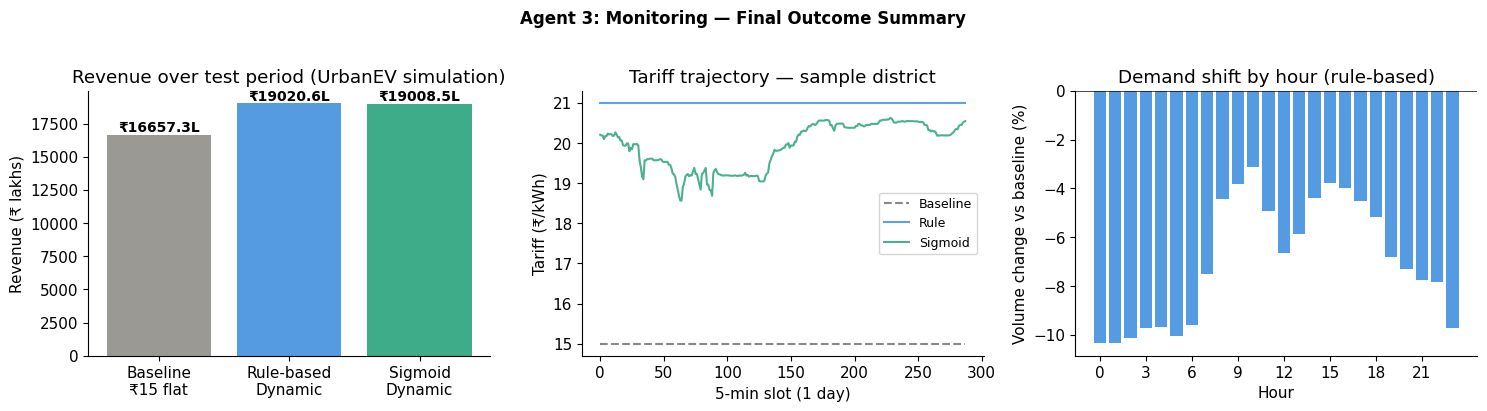

In [34]:
# ── FINAL VISUALISATION ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Agent 3: Monitoring — Final Outcome Summary',
             fontsize=12, fontweight='bold', y=1.02)

# Revenue comparison
ax = axes[0]
rev = [sim_rule['baseline_revenue'].sum()/1e5,
       sim_rule['dynamic_revenue'].sum()/1e5,
       sim_opt['dynamic_revenue'].sum()/1e5]
bars = ax.bar(['Baseline\n₹15 flat','Rule-based\nDynamic','Sigmoid\nDynamic'],
              rev, color=['#888780','#378ADD','#1D9E75'], alpha=0.85)
for b, v in zip(bars, rev):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(),
            f'₹{v:.1f}L', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Revenue (₹ lakhs)')
ax.set_title('Revenue over test period (UrbanEV simulation)')

# Single-day tariff
ax = axes[1]
did = test['district_id'].iloc[0]
day = test[test['district_id']==did].sort_values('datetime').head(288)
ax.plot(range(len(day)), [BASELINE_TARIFF_INR]*len(day), '--', color='#888', label='Baseline')
ax.plot(range(len(day)), day['tariff_rule_inr'].values, label='Rule', color='#378ADD', alpha=0.8)
ax.plot(range(len(day)), day['tariff_opt_inr'].values,  label='Sigmoid', color='#1D9E75', alpha=0.8)
ax.set_xlabel('5-min slot (1 day)'); ax.set_ylabel('Tariff (₹/kWh)')
ax.set_title('Tariff trajectory — sample district'); ax.legend(fontsize=9)

# Hourly demand shift
ax = axes[2]
uplift = sim_rule.groupby('hour_of_day').apply(
    lambda g: (g['adjusted_volume'].sum()-g['volume'].sum())/g['volume'].sum()*100
    if g['volume'].sum()>0 else 0)
ax.bar(uplift.index, uplift.values, color='#378ADD', alpha=0.85)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Hour'); ax.set_ylabel('Volume change vs baseline (%)')
ax.set_title('Demand shift by hour (rule-based)'); ax.set_xticks(range(0,24,3))
plt.tight_layout()
plt.savefig(f'{OUT_PATH}/phase5_summary.png', dpi=120, bbox_inches='tight')
plt.show()

---

# Summary and Results

> All values are from the actual executed run on the full dataset (247 UrbanEV districts, 14,884 ACN sessions).
> No sample-run numbers or formula predictions are reported.

---

## Agent 1 — Demand Prediction (UrbanEV, full 247-district run)

| Metric | Persistence Baseline | Random Forest | XGBoost | Interpretation |
|---|---|---|---|---|
| RMSE | 0.0915 | 0.0627 | **0.0578** | XGBoost 36.8% below baseline |
| MAE | 0.0516 | 0.0373 | **0.0353** | Avg error ~3.5% utilization |
| R² (overall) | 0.7292 | 0.8729 | **0.8917** | Partially inflated by stable periods |
| R² (transitions) | 0.2860 | — | **0.7579** | Genuine +0.47 gain where pricing matters |

**Stable vs Transition breakdown (actual execution):**

| Period | Rows | Baseline R² | XGBoost R² | Real Gain |
|---|---|---|---|---|
| Stable (delta < 0.01) | 131,877 | 0.9998 | 0.9750 | trivial — autocorrelation |
| Transition (delta ≥ 0.05) | 132,636 | 0.2860 | 0.7579 | **+0.4719 genuine skill** |

---

## Agent 2 — Tariff Pricing (actual simulation outputs)

| Zone | Condition | Tariff | Measured Outcome |
|---|---|---|---|
| Discount | pred_util < 0.15 (P25) | ₹10.5/kWh | +5.32% more sessions in off-peak slots |
| Neutral | 0.15 ≤ pred_util ≤ 0.38 | ₹15.0/kWh | 0% demand shift |
| Surge | pred_util > 0.38 (P75) | ₹21.0/kWh | −12.00% fewer sessions at peak slots |

---

## Agent 3 — Monitoring KPIs (actual measured values)

### UrbanEV-Based KPIs

| Metric | Rule-based | Sigmoid | How Computed |
|---|---|---|---|
| Charger Util BEFORE (all slots) | 28.8% | 28.8% | occupancy / total_chargers, historical avg |
| Charger Util BEFORE (peak only) | 52.0% | 38.5% | avg at surge-priced slots only |
| Charger Util AFTER (peak only) | 45.6% | 35.2% | adjusted_volume / total_chargers at surge slots |
| Demand Shift at Peak % | **−12.00%** | −7.63% | (adjusted − original) / original at surge slots |
| Off-Peak Uplift % | **+5.32%** | +2.53% | (adj_vol − vol) / vol at discount slots |
| Wait Time Reduction % (proxy) | **7.56%** | 7.08% | demand displaced / total demand |
| Revenue Gain % | **+14.19%** | +14.12% | (new − old) / old × 100 vs ₹15 baseline |

### ACN-Based KPIs (real kWhDelivered, Caltech peak 15–17 PM)

| Metric | Value | Note |
|---|---|---|
| Revenue Gain % (ACN validation) | **+5.21%** | Real kWh, Caltech tariff rule |
| Pricing Efficiency Score | **₹15.78/kWh** | Was ₹15.00/kWh (+₹0.78) |
| Customer Response Rate | **7.49%** | Avg demand shift/session via elasticity −0.30 |

---

##  Limitations

1. **Counterfactual simulation:** All UrbanEV demand shift numbers (−12%, +5.32%, 7.56%) come from elasticity = −0.30 applied mathematically — not from real observed behaviour. Real deployment would require live A/B testing to validate.

2. **Customer Response Rate is elasticity-derived:** The 7.49% is not measured from actual driver decisions. It is computed as `|−0.30 × price_change%|` averaged over ACN sessions. It represents a literature-based estimate.

3. **Cross-region limitation:** Model trained on Shenzhen taxi-pattern (night peak). Deployment in a campus or residential context requires retraining.

---

## Future Scope

1. **Live A/B testing:** Deploy dynamic pricing on a subset of districts to measure real elasticity and validate simulation assumptions.
2. **Reinforcement learning:** Frame as a Markov Decision Process with Revenue Gain as reward — enables the agent to learn pricing policy continuously.
3. **Before/after with real occupancy sensors:** Replace estimated "after" utilization with real sensor readings post-deployment.

---
